In [1]:
import fitness_landscape as fl
import os
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
fl.FitnessLandscape

AttributeError: module 'fitness_landscape' has no attribute 'FitnessLandscape'

### DMS and Megascale folding dataset

In [28]:
# Prepare file list
file_list = os.listdir('../data_files/megascale_folding/')
file_list = [file for file in file_list if file != '.DS_Store' or not file.startswith('megascale_folding_tmap')]
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/megascale_folding', file))

    # Extract sequence objects
    sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
    fitness = np.array(df['DMS_score'])

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences)}

    # Construct fitness landscape with Hamming graph for DMS data
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="hamming",
    )

    # Check if there is more than a single connected component and skip if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):
        continue

    # Attach fitness values
    layer_name = f"dms_score"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior='uniform')

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

0it [00:04, ?it/s]


KeyboardInterrupt: 

In [65]:
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")
out_json = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)


In [29]:
# Reload results
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")

with open(out_pkl, "rb") as f:
    results = pickle.load(f)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Build dataframe
# -----------------------------
rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": r["tmap"]["t_map"],
        "t_lo": r["tmap"]["t_lower_confidence_interval"],
        "t_hi": r["tmap"]["t_upper_confidence_interval"],
    })

df = pd.DataFrame(rows)

# Coerce numeric + drop non-finite
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t", "t_lo", "t_hi"]).reset_index(drop=True)

# -----------------------------
# Fix CI ordering (ensure lo <= hi)
# -----------------------------
lo = np.minimum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
hi = np.maximum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
df["t_lo"] = lo
df["t_hi"] = hi

# -----------------------------
# Drop poorly fitted datasets (avoid div-by-zero)
# -----------------------------
eps = 1e-300  # tiny, only to avoid division by zero
poor_fit = ((df["t_hi"] / np.maximum(df["t_lo"], eps)) >= 10.0) & (df["t_hi"] > 1.0)
df = df.loc[~poor_fit].reset_index(drop=True)

# -----------------------------
# Ensure t is inside [lo, hi]
# Boundary MAP values (e.g., t=1e-10) can fall just outside profile CI due to
# grid resolution / interpolation artifacts. Keep rows and expand CI to include t.
# -----------------------------
bad_low = df["t"] < df["t_lo"]
bad_high = df["t"] > df["t_hi"]
bad = bad_low | bad_high

df["ci_was_adjusted"] = bad

if bad.any():
    print("Rows where t is outside [t_lo, t_hi] (boundary-adjusting CI to include t):")
    print(df.loc[bad, ["dataset", "t", "t_lo", "t_hi"]])

    # Expand interval only as much as needed to include t.
    df.loc[bad_low, "t_lo"] = df.loc[bad_low, "t"]
    df.loc[bad_high, "t_hi"] = df.loc[bad_high, "t"]

    print(f"Adjusted CI bounds for {int(bad.sum())} datasets; no rows dropped.")

# -----------------------------
# Sort by t descending
# -----------------------------
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# -----------------------------
# Asymmetric error bars (guaranteed non-negative now)
# -----------------------------
t = df["t"].to_numpy()
t_lo = df["t_lo"].to_numpy()
t_hi = df["t_hi"].to_numpy()
yerr = np.vstack([t - t_lo, t_hi - t])


Rows where t is outside [t_lo, t_hi] (boundary-adjusting CI to include t):
        dataset             t      t_lo      t_hi
0    AMFR-HUMAN  1.000000e-10  0.001390  0.165536
1    BBC1-YEAST  1.000000e-10  0.001346  0.190704
4   CBPA2-HUMAN  1.000000e-10  0.000273  0.039470
10  EPHB2-HUMAN  1.000000e-10  0.001526  0.183802
11   FECA-ECOLI  1.000000e-10  0.001961  0.275463
14   ILF3-HUMAN  1.000000e-10  0.001876  0.257491
15   ISDH-STAAW  1.000000e-10  0.003285  0.386346
29   PSAE-SYNP2  1.000000e-10  0.001104  0.147166
35   RL20-AQUAE  7.068302e+00  6.362243  7.050505
37   RS15-GEOSE  1.000000e-10  0.008621  0.961607
39   SCIN-STAAR  1.000000e-10  0.007450  0.888060
40    SDA-BACSU  1.000000e-10  0.000486  0.066807
41    SPA-STAAU  1.000000e-10  0.002465  0.301450
44  SR43C-ARATH  5.693530e+00  5.297721  5.685768
46  TCRG1-MOUSE  5.693530e+00  5.335866  5.685860
48  TNKS2-HUMAN  1.000000e-10  0.006755  0.838442
50   UBR5-HUMAN  1.000000e-10  0.002244  0.305870
52   VILI-CHICK  1.000000

## Robustness and mechanism follow-ups for Figure 2 (36 DMS domains)

The cells below add four reviewer-oriented checks on the same 36-domain subset used in the main bar plot:

1. Null permutation model for `t_MAP` (small initial `n_perm`, focused on smoothest and most rugged domains).
2. Regression of `t_MAP` against per-domain fitness-distribution summaries.
3. Regression of `t_MAP` against simple structure-derived predictors from each domain's PDB entry.
4. Graph-size robustness by downsampling each domain to the smallest number of measured variants.

Note: replicate counts are intentionally small for iteration speed. Increase these for final statistics.


In [31]:
from pathlib import Path
import re
import requests
from scipy.spatial.distance import pdist, squareform
from scipy.stats import skew, percentileofscore, spearmanr, pearsonr, linregress, f as f_dist, wilcoxon
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DMS_DIR = Path('../data_files/protein_gym/DMS_assays_substitutions')
PDB_CACHE_DIR = Path('../data_files/pdb_cache')
PDB_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_dms_tmap_table(results, apply_poor_fit_filter=True, clamp_ci_to_t=True, verbose=True):
    rows = []
    for r in results:
        file_name = r['file']
        dataset = '-'.join(file_name.replace('.csv', '').split('_')[0:2])
        rows.append({
            'dataset': dataset,
            'file': file_name,
            'filepath': str(DMS_DIR / file_name),
            'n_sequences': int(r.get('n_sequences', np.nan)),
            't': float(r['tmap']['t_map']),
            't_lo': float(r['tmap']['t_lower_confidence_interval']),
            't_hi': float(r['tmap']['t_upper_confidence_interval']),
        })

    table = pd.DataFrame(rows)
    n_raw = len(table)

    for c in ['t', 't_lo', 't_hi']:
        table[c] = pd.to_numeric(table[c], errors='coerce')

    table = table.replace([np.inf, -np.inf], np.nan).dropna(subset=['t', 't_lo', 't_hi']).reset_index(drop=True)
    n_after_finite = len(table)

    lo = np.minimum(table['t_lo'].to_numpy(), table['t_hi'].to_numpy())
    hi = np.maximum(table['t_lo'].to_numpy(), table['t_hi'].to_numpy())
    table['t_lo'] = lo
    table['t_hi'] = hi

    eps = 1e-300
    poor_fit = ((table['t_hi'] / np.maximum(table['t_lo'], eps)) >= 10.0) & (table['t_hi'] > 1.0)
    table['poor_fit'] = poor_fit

    if apply_poor_fit_filter:
        table = table.loc[~poor_fit].reset_index(drop=True)

    bad_low = table['t'] < table['t_lo']
    bad_high = table['t'] > table['t_hi']
    bad = bad_low | bad_high
    table['ci_was_adjusted'] = bad

    if clamp_ci_to_t:
        table.loc[bad_low, 't_lo'] = table.loc[bad_low, 't']
        table.loc[bad_high, 't_hi'] = table.loc[bad_high, 't']

    if verbose:
        n_poor = int(poor_fit.sum())
        n_ci = int(bad.sum())
        print(
            f'Table build counts: raw={n_raw}, after_finite={n_after_finite}, '
            f'poor_fit_removed={n_poor if apply_poor_fit_filter else 0}, '
            f'ci_adjusted={n_ci}, final={len(table)}'
        )
        if n_ci > 0:
            print('CI-adjusted examples (first 10):')
            print(table.loc[bad, ['dataset', 't', 't_lo', 't_hi']].head(10))

    table = table.sort_values('t', ascending=False).reset_index(drop=True)
    return table


def regression_global_f_pvalue(y_true, y_pred, n_features):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = len(y_true)
    p = int(n_features)

    if n <= p + 1 or n < 3:
        return np.nan, np.nan

    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_reg = ss_tot - ss_res

    if not np.isfinite(ss_tot) or ss_tot <= 0:
        return np.nan, np.nan

    df_model = p
    df_resid = n - p - 1

    if df_model <= 0 or df_resid <= 0:
        return np.nan, np.nan

    ms_reg = ss_reg / df_model
    ms_res = ss_res / df_resid

    if ms_res <= 0:
        if ms_reg > 0:
            return np.inf, 0.0
        return np.nan, np.nan

    f_stat = ms_reg / ms_res
    p_value = float(f_dist.sf(f_stat, df_model, df_resid))
    return float(f_stat), p_value


dms_tmap_df = build_dms_tmap_table(results, apply_poor_fit_filter=False, clamp_ci_to_t=True, verbose=True)
print(f'Retained domains after Figure 2 filtering: {len(dms_tmap_df)}')
dms_tmap_df.head()


Table build counts: raw=64, after_finite=64, poor_fit_removed=0, ci_adjusted=24, final=64
CI-adjusted examples (first 10):
        dataset             t          t_lo      t_hi
0    AMFR-HUMAN  1.000000e-10  1.000000e-10  0.165536
1    ARGR-ECOLI  1.000000e-10  1.000000e-10  2.290137
2    BBC1-YEAST  1.000000e-10  1.000000e-10  0.190704
5   CBPA2-HUMAN  1.000000e-10  1.000000e-10  0.039470
9    DN7A-SACS2  1.000000e-10  1.000000e-10  1.468556
12  EPHB2-HUMAN  1.000000e-10  1.000000e-10  0.183802
13   FECA-ECOLI  1.000000e-10  1.000000e-10  0.275463
17   ILF3-HUMAN  1.000000e-10  1.000000e-10  0.257491
18   ISDH-STAAW  1.000000e-10  1.000000e-10  0.386346
30   PKN1-HUMAN  1.000000e-10  1.000000e-10  2.277404
Retained domains after Figure 2 filtering: 64


,dataset,file,filepath,n_sequences,t,t_lo,t_hi,poor_fit,ci_was_adjusted
0,RL20-AQUAE,RL20_AQUAE_Tsuboyama_2023_1GYZ.csv,../data_files/protein_gym/DMS_assays_substitut...,1461,7.068302,6.362243,7.068302,False,True
1,SR43C-ARATH,SR43C_ARATH_Tsuboyama_2023_2N88.csv,../data_files/protein_gym/DMS_assays_substitut...,1583,5.693530,5.297721,5.693530,False,True
2,TCRG1-MOUSE,TCRG1_MOUSE_Tsuboyama_2023_1E0L.csv,../data_files/protein_gym/DMS_assays_substitut...,1058,5.693530,5.335866,5.693530,False,True
3,MAFG-MOUSE,MAFG_MOUSE_Tsuboyama_2023_1K1V.csv,../data_files/protein_gym/DMS_assays_substitut...,1429,5.393842,5.115799,5.567087,False,False
4,VG08-BPP22,VG08_BPP22_Tsuboyama_2023_2GP8.csv,../data_files/protein_gym/DMS_assays_substitut...,723,5.109929,4.406082,5.374070,False,False


In [32]:
MUT_TOKEN_RE = re.compile(r'([A-Z])(\d+)([A-Z\*])')


def load_domain_dataframe(file_name):
    domain_df = pd.read_csv(DMS_DIR / file_name)
    domain_df = domain_df.replace([np.inf, -np.inf], np.nan)
    domain_df = domain_df.dropna(subset=['mutated_sequence', 'DMS_score']).reset_index(drop=True)
    return domain_df


def build_hamming_landscape_from_df(domain_df):
    sequences = [fl.BaseNumpySequence(seq) for seq in domain_df['mutated_sequence']]
    fitness = domain_df['DMS_score'].to_numpy(dtype=float)

    landscape = fl.FitnessLandscape.build(
        sequences,
        graph='hamming',
    )

    if not nx.is_connected(landscape.graph):
        raise ValueError('Sampled landscape is disconnected.')

    return landscape, fitness


def compute_tmap_on_landscape_values(
    landscape,
    values,
    eigenvalues=None,
    eigenvectors=None,
    layer_name='tmp_layer',
    detach=True,
    t_min=1e-10,
    t_max=1e2,
    prior='uniform',
):
    values = np.asarray(values, dtype=float)
    landscape.attach(name=layer_name, values=values, dtype='numeric')
    landscape.view(layer_name)

    tmap_kwargs = {
        't_min': t_min,
        't_max': t_max,
        'prior': prior,
    }

    # Reuse precomputed graph-spectrum basis when provided.
    if eigenvalues is not None and eigenvectors is not None:
        tmap_kwargs['_eigenvalues'] = np.asarray(eigenvalues, dtype=float)
        tmap_kwargs['_eigenvectors'] = np.asarray(eigenvectors, dtype=float)

    try:
        tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
            landscape,
            **tmap_kwargs,
        )
    finally:
        if detach:
            landscape.detach(layer_name)

    return float(tmap_res['t_map'])



def infer_wildtype_sequence(domain_df):
    wt_seq = list(domain_df['mutated_sequence'].iloc[0])

    if 'mutant' not in domain_df.columns:
        return ''.join(wt_seq)

    for mutant in domain_df['mutant'].astype(str):
        for token in mutant.split(':'):
            match = MUT_TOKEN_RE.fullmatch(token.strip())
            if not match:
                continue

            wt_aa, pos_str, _ = match.groups()
            idx = int(pos_str) - 1

            if 0 <= idx < len(wt_seq):
                wt_seq[idx] = wt_aa

    return ''.join(wt_seq)


def estimate_wt_fitness(domain_df):
    if 'mutant' in domain_df.columns:
        wt_mask = domain_df['mutant'].astype(str).str.upper().eq('WT')
        if wt_mask.any():
            return float(domain_df.loc[wt_mask, 'DMS_score'].iloc[0]), 'explicit_wt_row'

    wt_seq = infer_wildtype_sequence(domain_df)
    seq_mask = domain_df['mutated_sequence'].astype(str).eq(wt_seq)
    if seq_mask.any():
        return float(domain_df.loc[seq_mask, 'DMS_score'].iloc[0]), 'inferred_wt_sequence'

    # ProteinGym substitution sets are often centered around WT ~= 0.
    return 0.0, 'assumed_zero'


def domain_fitness_summary(domain_df):
    values = domain_df['DMS_score'].to_numpy(dtype=float)
    wt_score, wt_source = estimate_wt_fitness(domain_df)

    mean_val = float(values.mean())
    std_val = float(values.std(ddof=0))

    return {
        'fitness_mean': mean_val,
        'fitness_variance': float(values.var(ddof=0)),
        'fitness_skewness': float(skew(values, bias=False, nan_policy='omit')) if len(values) >= 3 else np.nan,
        'wt_score': wt_score,
        'wt_score_source': wt_source,
        'wt_minus_mean': wt_score - mean_val,
        'wt_zscore': (wt_score - mean_val) / std_val if std_val > 0 else np.nan,
        'wt_percentile': float(percentileofscore(values, wt_score, kind='mean')),
        'n_variants': int(len(values)),
    }


Permutation tests:   0%|          | 0/2 [00:00<?, ?it/s]

Permutation tests: 100%|██████████| 2/2 [03:00<00:00, 90.15s/it]


,dataset,observed_t_map,null_mean_t_map,null_std_t_map,z_score_vs_null,p_empirical_two_sided,percentile_vs_null,n_perm
0,RL20-AQUAE,7.068302e+00,0.127833,0.225032,30.842132,0.019802,100.0,100
1,AMFR-HUMAN,1.000000e-10,0.231119,0.489953,-0.471717,1.000000,0.0,100


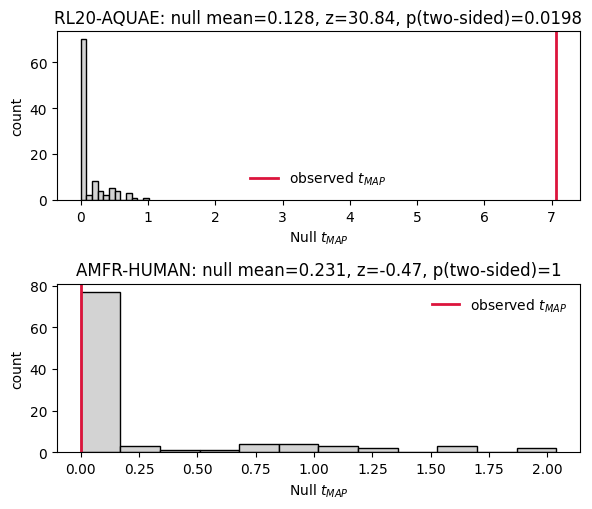

In [ ]:
# 1) Null model: permute fitness values on the fixed Hamming graph.
# Small initial replicate count for quick iteration.
PERMUTATION_REPS = 100
TAIL_SIZE = 1  # smoothest and rugged tails to evaluate first
rng = np.random.default_rng(123)

from fitness_landscape.transforms.eigenmode import eigenmode_decomposition

selected_perm_domains = pd.concat(
    [dms_tmap_df.head(TAIL_SIZE), dms_tmap_df.tail(TAIL_SIZE)],
    axis=0,
).drop_duplicates(subset='file').reset_index(drop=True)

perm_rows = []
for row in tqdm(selected_perm_domains.itertuples(index=False), total=len(selected_perm_domains), desc='Permutation tests'):
    domain_df = load_domain_dataframe(row.file)
    landscape, fitness = build_hamming_landscape_from_df(domain_df)

    # Graph topology is fixed across permutations for this domain; compute spectrum once.
    eigvals, eigvecs = eigenmode_decomposition(
        landscape,
        matrix='norm_laplacian',
    )

    null_t_values = []
    for rep in range(PERMUTATION_REPS):
        perm_values = rng.permutation(fitness)
        t_perm = compute_tmap_on_landscape_values(
            landscape,
            perm_values,
            eigenvalues=eigvals,
            eigenvectors=eigvecs,
            layer_name=f'perm_{rep}',
            detach=True,
        )
        null_t_values.append(t_perm)

    null_arr = np.asarray(null_t_values, dtype=float)
    null_mean = float(null_arr.mean())
    null_std = float(null_arr.std(ddof=1)) if len(null_arr) > 1 else np.nan

    observed = float(row.t)
    z_score = (observed - null_mean) / null_std if np.isfinite(null_std) and null_std > 0 else np.nan

    # Empirical permutation p-values with +1 correction.
    n_perm = len(null_arr)
    p_empirical_high = float((np.sum(null_arr >= observed) + 1) / (n_perm + 1))
    p_empirical_low = float((np.sum(null_arr <= observed) + 1) / (n_perm + 1))
    p_empirical_two_sided = float(min(1.0, 2.0 * min(p_empirical_high, p_empirical_low)))

    percentile_rank = float(np.mean(null_arr < observed) * 100.0)

    perm_rows.append({
        'dataset': row.dataset,
        'file': row.file,
        'observed_t_map': observed,
        'null_mean_t_map': null_mean,
        'null_std_t_map': null_std,
        'null_min_t_map': float(null_arr.min()),
        'null_max_t_map': float(null_arr.max()),
        'z_score_vs_null': z_score,
        'p_empirical_high': p_empirical_high,
        'p_empirical_low': p_empirical_low,
        'p_empirical_two_sided': p_empirical_two_sided,
        'percentile_vs_null': percentile_rank,
        'n_perm': int(n_perm),
        'n_eigenvalues': int(len(eigvals)),
        'null_samples': null_t_values,
    })

perm_results_df = pd.DataFrame(perm_rows).sort_values('observed_t_map', ascending=False).reset_index(drop=True)
display(
    perm_results_df[
        [
            'dataset',
            'observed_t_map',
            'null_mean_t_map',
            'null_std_t_map',
            'z_score_vs_null',
            'p_empirical_two_sided',
            'percentile_vs_null',
            'n_perm',
        ]
    ]
)


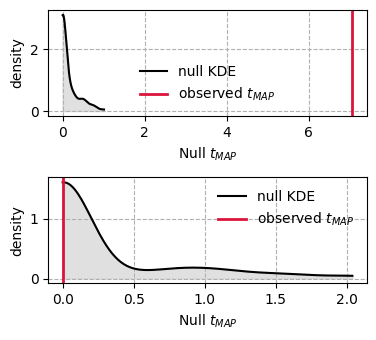

In [22]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(
    len(perm_results_df), 1,
    figsize=(4, 1.75 * len(perm_results_df)),
    squeeze=False
)

for ax, row in zip(axes.ravel(), perm_results_df.itertuples(index=False)):
    samples = np.asarray(row.null_samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if len(samples) >= 2 and np.std(samples) > 0:
        x_grid = np.linspace(samples.min(), samples.max(), 300)
        kde = gaussian_kde(samples)
        y_kde = kde(x_grid)

        ax.plot(x_grid, y_kde, color='black', lw=1.5, label='null KDE')
        ax.fill_between(x_grid, 0, y_kde, color='lightgrey', alpha=0.7)
    else:
        # Fallback if too few/degenerate samples
        ax.axvline(samples[0] if len(samples) else row.null_mean_t_map, color='black', lw=1.5, label='null KDE (degenerate)')
    ax.grid(True, linestyle="--")
    ax.axvline(row.observed_t_map, color='crimson', lw=2, label='observed $t_{MAP}$')
    ax.set_xlabel(r'Null $t_{MAP}$')
    ax.set_ylabel('density')
    ax.legend(frameon=False)
    

plt.tight_layout()
plt.savefig('../figures/figure_2/permutation_test_kde.pdf')
plt.show()


In [8]:
### All permutation testing here
# Full-domain permutation null model with one eigendecomposition per system.
try:
    from fitness_landscape.transforms.eigenmode import eigenmode_decomposition
except Exception:
    # Fallback for environments where eigenmode lives under analysis.
    from fitness_landscape.analysis.eigenmode import eigenmode_decomposition

ALL_PERMUTATION_REPS = 100
ALL_PERMUTATION_SEED = 2026
ALL_PERM_INCLUDE_WIDE_COLUMNS = False  # set True to add perm_t_map_000... columns

perm_rng = np.random.default_rng(ALL_PERMUTATION_SEED)


def _domain_eigenpairs(landscape):
    """Try normalized Laplacian first; fallback to Laplacian if needed."""
    for matrix_name in ('norm_laplacian', 'laplacian'):
        try:
            eigvals, eigvecs = eigenmode_decomposition(landscape, matrix=matrix_name)
            return np.asarray(eigvals, dtype=float), np.asarray(eigvecs, dtype=float), matrix_name
        except Exception:
            continue
    raise RuntimeError('Failed to compute eigenpairs with both norm_laplacian and laplacian backends.')


all_perm_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='All-domain permutation tests'):
    out = {
        'system_name': row.dataset,
        'dataset': row.dataset,
        'file': row.file,
        'status': 'ok',
        'error': '',
        'n_perm': int(ALL_PERMUTATION_REPS),
    }

    try:
        domain_df = load_domain_dataframe(row.file)
        landscape, fitness = build_hamming_landscape_from_df(domain_df)

        # Compute eigenpairs ONCE for this system and reuse for observed and every permutation.
        eigvals, eigvecs, eig_matrix = _domain_eigenpairs(landscape)

        observed_t = compute_tmap_on_landscape_values(
            landscape,
            fitness,
            eigenvalues=eigvals,
            eigenvectors=eigvecs,
            layer_name='perm_all_observed',
            detach=True,
        )

        perm_t_maps = []
        for rep in range(ALL_PERMUTATION_REPS):
            perm_values = perm_rng.permutation(fitness)
            t_perm = compute_tmap_on_landscape_values(
                landscape,
                perm_values,
                eigenvalues=eigvals,
                eigenvectors=eigvecs,
                layer_name=f'perm_all_{rep}',
                detach=True,
            )
            perm_t_maps.append(float(t_perm))

        perm_arr = np.asarray(perm_t_maps, dtype=float)
        null_mean = float(np.mean(perm_arr))
        null_std = float(np.std(perm_arr, ddof=1)) if len(perm_arr) > 1 else np.nan
        z_vs_null = (observed_t - null_mean) / null_std if np.isfinite(null_std) and null_std > 0 else np.nan

        n_perm = int(len(perm_arr))
        p_high = float((np.sum(perm_arr >= observed_t) + 1) / (n_perm + 1))
        p_low = float((np.sum(perm_arr <= observed_t) + 1) / (n_perm + 1))
        p_two_sided = float(min(1.0, 2.0 * min(p_high, p_low)))
        percentile_vs_null = float(np.mean(perm_arr < observed_t) * 100.0)

        out.update({
            'observed_t_map': float(observed_t),
            'observed_t_map_input_df': float(row.t),
            'null_mean_t_map': null_mean,
            'null_std_t_map': null_std,
            'null_min_t_map': float(np.min(perm_arr)),
            'null_max_t_map': float(np.max(perm_arr)),
            'z_score_vs_null': float(z_vs_null) if np.isfinite(z_vs_null) else np.nan,
            'p_empirical_high': p_high,
            'p_empirical_low': p_low,
            'p_empirical_two_sided': p_two_sided,
            'p_value': p_two_sided,
            'percentile_vs_null': percentile_vs_null,
            'n_perm': n_perm,
            'n_eigenvalues': int(len(np.ravel(eigvals))),
            'eigenpair_matrix': eig_matrix,
            'perm_t_maps': perm_t_maps,
        })

        if ALL_PERM_INCLUDE_WIDE_COLUMNS:
            for i, tval in enumerate(perm_t_maps):
                out[f'perm_t_map_{i:03d}'] = float(tval)

    except Exception as exc:
        out.update({
            'status': 'error',
            'error': str(exc),
            'observed_t_map': np.nan,
            'observed_t_map_input_df': float(row.t) if pd.notna(row.t) else np.nan,
            'null_mean_t_map': np.nan,
            'null_std_t_map': np.nan,
            'null_min_t_map': np.nan,
            'null_max_t_map': np.nan,
            'z_score_vs_null': np.nan,
            'p_empirical_high': np.nan,
            'p_empirical_low': np.nan,
            'p_empirical_two_sided': np.nan,
            'p_value': np.nan,
            'percentile_vs_null': np.nan,
            'n_eigenvalues': np.nan,
            'eigenpair_matrix': '',
            'perm_t_maps': [],
        })

    all_perm_rows.append(out)

all_perm_results_df = pd.DataFrame(all_perm_rows).sort_values('observed_t_map', ascending=False, na_position='last').reset_index(drop=True)

display_cols = [
    'system_name', 'file', 'status', 'observed_t_map', 'null_mean_t_map',
    'z_score_vs_null', 'p_value', 'percentile_vs_null', 'n_perm', 'n_eigenvalues', 'eigenpair_matrix',
]
display(all_perm_results_df[display_cols])

# Optional tidy form (one row per permutation sample) for downstream plotting/tests.
all_perm_long_df = (
    all_perm_results_df.loc[all_perm_results_df['status'] == 'ok', ['system_name', 'dataset', 'file', 'observed_t_map', 'perm_t_maps']]
    .explode('perm_t_maps')
    .rename(columns={'perm_t_maps': 'perm_t_map'})
    .reset_index(drop=True)
)
if len(all_perm_long_df):
    all_perm_long_df['perm_t_map'] = all_perm_long_df['perm_t_map'].astype(float)

print(f'Built all_perm_results_df with {len(all_perm_results_df)} systems.')
print(f"Status counts: {all_perm_results_df['status'].value_counts().to_dict()}")
print(f'Built all_perm_long_df with {len(all_perm_long_df)} rows.')



All-domain permutation tests:   9%|▉         | 6/64 [03:50<30:00, 31.04s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/transforms/eigenmode.py:87: RuntimeWarning: Computing all eigenpairs for a large graph; this may be slow or memory-intensive. Pass k to compute a truncated basis instead.
  warnings.warn(
All-domain permutation tests: 100%|██████████| 64/64 [1:13:59<00:00, 69.36s/it] 


,system_name,file,status,observed_t_map,null_mean_t_map,z_score_vs_null,p_value,percentile_vs_null,n_perm,n_eigenvalues,eigenpair_matrix
0,RL20-AQUAE,RL20_AQUAE_Tsuboyama_2023_1GYZ.csv,ok,7.068302e+00,1.245511e-01,33.754891,0.019802,100.0,100,1461,norm_laplacian
1,SR43C-ARATH,SR43C_ARATH_Tsuboyama_2023_2N88.csv,ok,5.693530e+00,7.941425e-02,43.711932,0.019802,100.0,100,1583,norm_laplacian
2,TCRG1-MOUSE,TCRG1_MOUSE_Tsuboyama_2023_1E0L.csv,ok,5.693530e+00,1.092956e-01,34.607171,0.019802,100.0,100,1058,norm_laplacian
3,MAFG-MOUSE,MAFG_MOUSE_Tsuboyama_2023_1K1V.csv,ok,5.393842e+00,1.104667e-01,24.159427,0.019802,100.0,100,1429,norm_laplacian
4,VG08-BPP22,VG08_BPP22_Tsuboyama_2023_2GP8.csv,ok,5.109929e+00,1.057160e-01,11.549027,0.019802,100.0,100,723,norm_laplacian
...,...,...,...,...,...,...,...,...,...,...,...
59,CBPA2-HUMAN,CBPA2_HUMAN_Tsuboyama_2023_1O6X.csv,ok,1.000000e-10,1.000000e-10,0.994987,1.000000,0.0,100,2068,norm_laplacian
60,BBC1-YEAST,BBC1_YEAST_Tsuboyama_2023_1TG0.csv,ok,1.000000e-10,1.000000e-10,0.994987,1.000000,0.0,100,2069,norm_laplacian
61,ILF3-HUMAN,ILF3_HUMAN_Tsuboyama_2023_2L33.csv,ok,1.000000e-10,1.000000e-10,0.994987,1.000000,0.0,100,1329,norm_laplacian
62,RS15-GEOSE,RS15_GEOSE_Tsuboyama_2023_1A32.csv,ok,1.000000e-10,1.000000e-10,0.994987,1.000000,0.0,100,1195,norm_laplacian


Built all_perm_results_df with 64 systems.
Status counts: {'ok': 64}
Built all_perm_long_df with 6400 rows.


In [14]:
# Save permutation DF
all_perm_results_df.to_csv('../data_files/protein_gym/DMS_assays_substitutions/folding_permutation_short.df', index=None)
all_perm_long_df.to_csv('../data_files/protein_gym/DMS_assays_substitutions/folding_permutation_long.df', index=None)

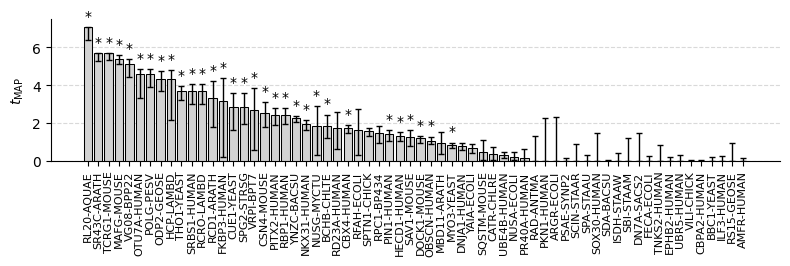

Starred 31/64 domains at permutation alpha=0.05.


In [33]:
# SEARCH_TAG: TMAP_BAR_WITH_PERM_SIGNIFICANCE
# Remake t_MAP barplot with permutation-significance stars.
PERM_STAR_ALPHA = 0.05

if 'all_perm_results_df' not in globals():
    raise RuntimeError('Run the all-domain permutation testing cell first (requires all_perm_results_df).')
if 'dms_tmap_df' not in globals():
    raise RuntimeError('Run the t_MAP table cell first (requires dms_tmap_df).')

# Choose permutation p-value column.
perm_df = all_perm_results_df.copy()
if 'status' in perm_df.columns:
    perm_df = perm_df.loc[perm_df['status'] == 'ok'].copy()

if 'p_value' in perm_df.columns:
    p_col = 'p_value'
elif 'p_empirical_two_sided' in perm_df.columns:
    p_col = 'p_empirical_two_sided'
else:
    raise RuntimeError('Permutation results must include p_value or p_empirical_two_sided.')

# Build plotting frame (same core structure as the original bar plot).
df = dms_tmap_df.copy().sort_values('t', ascending=False).reset_index(drop=True)
df = df.merge(
    perm_df[['file', p_col]].rename(columns={p_col: 'perm_p_value'}),
    on='file',
    how='left',
)

t = df['t'].to_numpy(dtype=float)
yerr = np.vstack([
    np.clip(t - df['t_lo'].to_numpy(dtype=float), a_min=0.0, a_max=None),
    np.clip(df['t_hi'].to_numpy(dtype=float) - t, a_min=0.0, a_max=None),
])

# -----------------------------
# Plot (single bar call; x aligned with errorbar)
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(8, 2.75))

ax.bar(
    x,
    t,
    color='lightgrey',
    edgecolor='black',
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=x,
    y=t,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    elinewidth=1,
    capsize=2,
    zorder=3
)

# Add '*' above bars with significant permutation p-value.
sig_mask = np.isfinite(df['perm_p_value'].to_numpy(dtype=float)) & (df['perm_p_value'].to_numpy(dtype=float) < PERM_STAR_ALPHA)
if np.any(sig_mask):
    upper = t + yerr[1]
    y_min = float(np.nanmin(np.r_[0.0, t]))
    y_max = float(np.nanmax(upper))
    pad = 0.03 * (y_max - y_min + 1e-12)
    star_y = upper + pad

    for xi, yi, is_sig in zip(x, star_y, sig_mask):
        if is_sig:
            ax.text(xi, yi, '*', ha='center', va='bottom', fontsize=10, color='black', zorder=4)

    # Ensure stars are visible.
    ax.set_ylim(top=float(np.nanmax(star_y) + pad))

step = 1  # change to 3 if you truly want every 3rd label
ax.set_xticks(x[::step])
ax.set_xticklabels(df['dataset'].iloc[::step], rotation=90, fontsize=8)

ax.set_ylabel(r'$t_{\mathrm{MAP}}$')
# ax.set_yscale('log')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', ls='--', c='0.85', zorder=1)

plt.tight_layout()
plt.savefig('../figures/figure_2/tmap_vs_dms.pdf')
plt.show()

n_sig = int(np.sum(sig_mask))
print(f'Starred {n_sig}/{len(df)} domains at permutation alpha={PERM_STAR_ALPHA:.3g}.')



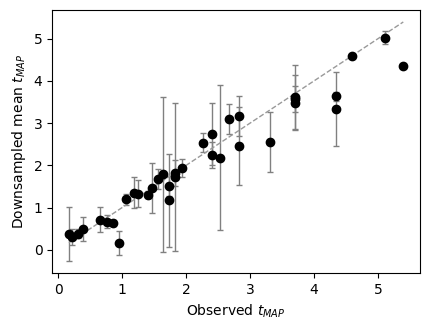

In [ ]:
# 4) Subsample control: downsample all domains to the smallest domain size.
SUBSAMPLE_REPS = 3  # small initial setting for turnaround speed
MAX_ATTEMPTS_FACTOR = 20
subsample_rng = np.random.default_rng(2026)

target_n = int(dms_tmap_df['n_sequences'].min())
print(f'Downsampling each domain to n={target_n} variants.')

subsample_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='Downsampling'):
    domain_df = load_domain_dataframe(row.file)
    sample_t_values = []

    max_attempts = max(SUBSAMPLE_REPS * MAX_ATTEMPTS_FACTOR, 20)
    attempts = 0

    while len(sample_t_values) < SUBSAMPLE_REPS and attempts < max_attempts:
        attempts += 1

        if len(domain_df) == target_n:
            sample_df = domain_df
        else:
            chosen_idx = subsample_rng.choice(len(domain_df), size=target_n, replace=False)
            sample_df = domain_df.iloc[chosen_idx].reset_index(drop=True)

        try:
            sample_landscape, sample_fitness = build_hamming_landscape_from_df(sample_df)
        except ValueError:
            continue

        sample_t = compute_tmap_on_landscape_values(
            sample_landscape,
            sample_fitness,
            layer_name='sampled_fitness',
            detach=True,
        )
        sample_t_values.append(sample_t)

        if len(domain_df) == target_n:
            break

    arr = np.asarray(sample_t_values, dtype=float)

    subsample_rows.append(
        {
            'dataset': row.dataset,
            'file': row.file,
            'observed_t_map': float(row.t),
            'downsample_t_mean': float(arr.mean()) if len(arr) else np.nan,
            'downsample_t_std': float(arr.std(ddof=1)) if len(arr) > 1 else 0.0,
            'successful_reps': int(len(arr)),
            'attempts': int(attempts),
            'downsample_samples': sample_t_values,
        }
    )

subsample_df = pd.DataFrame(subsample_rows)
rank_compare_df = dms_tmap_df.merge(
    subsample_df[['file', 'downsample_t_mean', 'downsample_t_std', 'successful_reps']],
    on='file',
    how='left',
)

valid_rank_df = rank_compare_df.dropna(subset=['t', 'downsample_t_mean']).reset_index(drop=True)
if len(valid_rank_df) >= 3:
    rho, p_spearman = spearmanr(valid_rank_df['t'], valid_rank_df['downsample_t_mean'])
    r_pearson, p_pearson = pearsonr(valid_rank_df['t'].to_numpy(float), valid_rank_df['downsample_t_mean'].to_numpy(float))

    print(
        f'Spearman correlation (observed vs downsampled mean t_MAP): '
        f'rho={rho:.3f}, p={p_spearman:.3g}, n={len(valid_rank_df)}'
    )
    print(
        f'Pearson correlation (observed vs downsampled mean t_MAP): '
        f'r={r_pearson:.3f}, p={p_pearson:.3g}, n={len(valid_rank_df)}'
    )

    if len(valid_rank_df) >= 5:
        try:
            w_stat, p_wilcoxon = wilcoxon(
                valid_rank_df['t'].to_numpy(float),
                valid_rank_df['downsample_t_mean'].to_numpy(float),
                alternative='two-sided',
                zero_method='wilcox',
            )
            print(
                f'Paired Wilcoxon test (observed vs downsampled mean t_MAP): '
                f'W={w_stat:.3f}, p={p_wilcoxon:.3g}'
            )
        except ValueError as exc:
            print(f'Paired Wilcoxon test not computed: {exc}')

rank_out = valid_rank_df.sort_values('t', ascending=False).reset_index(drop=True)
display(rank_out[['dataset', 't', 'downsample_t_mean', 'downsample_t_std', 'successful_reps']])

plt.figure(figsize=(4.4, 3.4))
plt.errorbar(
    rank_out['t'],
    rank_out['downsample_t_mean'],
    yerr=rank_out['downsample_t_std'],
    fmt='o',
    color='black',
    ecolor='grey',
    elinewidth=1,
    capsize=2,
)

xy_min = float(min(rank_out['t'].min(), rank_out['downsample_t_mean'].min()))
xy_max = float(max(rank_out['t'].max(), rank_out['downsample_t_mean'].max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], ls='--', c='0.6', lw=1)

plt.xlabel('Observed $t_{MAP}$')
plt.ylabel('Downsampled mean $t_{MAP}$')
# plt.title('Graph-size robustness')
plt.tight_layout()
plt.savefig('../figures/SI_figures/SI_figure_DMS/graph_size_sampling_vs_tmap.pdf')
plt.show()


DMS substitution-matrix dimensionality:   0%|          | 0/64 [00:00<?, ?it/s]

,dataset,t_map,submat_rows_used,submat_n_components_90,submat_effective_dimensionality,submat_sv1_fraction,error
0,RL20-AQUAE,7.068302e+00,59,7,5.014349,0.551905,
1,SR43C-ARATH,5.693530e+00,48,9,7.675831,0.418464,
2,TCRG1-MOUSE,5.693530e+00,34,7,6.341623,0.391416,
3,MAFG-MOUSE,5.393842e+00,41,6,5.382006,0.484861,
4,VG08-BPP22,5.109929e+00,40,7,5.583069,0.527033,
...,...,...,...,...,...,...,...
59,CBPA2-HUMAN,1.000000e-10,72,7,5.263237,0.527244,
60,BBC1-YEAST,1.000000e-10,64,10,8.992507,0.350003,
61,ILF3-HUMAN,1.000000e-10,71,7,5.817783,0.498859,
62,RS15-GEOSE,1.000000e-10,63,6,4.547944,0.602932,


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,slope,slope_p,n_domains
0,submat_n_components_90,-0.168892,0.182167,-0.092661,0.466461,-0.221769,0.182167,64
1,submat_n_components_80,-0.130761,0.303057,-0.027314,0.830353,-0.184088,0.303057,64
2,submat_effective_dimensionality,-0.102223,0.421525,-0.034757,0.785114,-0.109670,0.421525,64
3,submat_spectrum_entropy,-0.098382,0.439274,-0.034757,0.785114,-0.778865,0.439274,64
4,submat_participation_ratio,-0.046805,0.713422,0.001096,0.993144,-0.061873,0.713422,64
5,submat_sv1_fraction,0.012317,0.923043,-0.016318,0.898165,0.255549,0.923043,64


Multivariate dimensionality model: R^2=0.139, F=1.530, p=0.185, n=64


,feature,standardized_coef,stdcoef_t_stat,stdcoef_p_value
2,submat_effective_dimensionality,-14.152431,-1.941393,0.057160
3,submat_participation_ratio,7.732635,1.841275,0.070787
4,submat_spectrum_entropy,7.187296,1.377269,0.173814
5,submat_sv1_fraction,1.787779,0.744124,0.459858
0,submat_n_components_80,0.715124,0.735213,0.465224
1,submat_n_components_90,0.312906,0.372879,0.710621


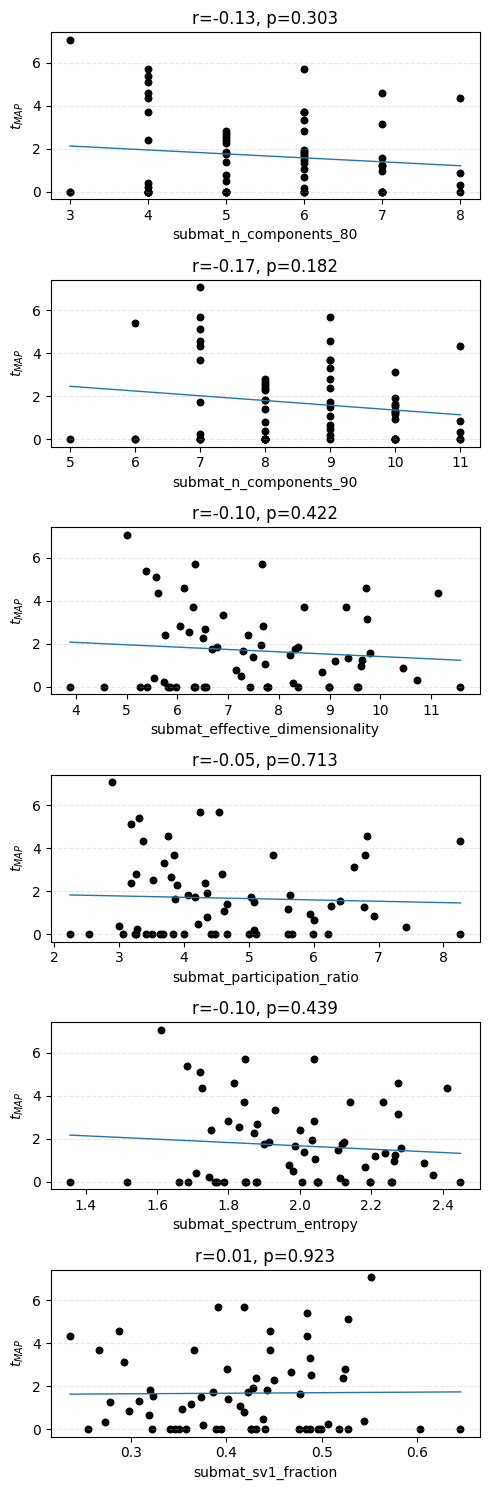

In [34]:
# Experiment 7: DMS-only substitution-matrix effective dimensionality vs ruggedness.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import pearsonr, spearmanr, linregress, f as f_dist
from scipy.stats import t as student_t
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

AA20_DMS = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_DMS = re.compile(r'([A-Z])([0-9]+)([A-Z])')


def _parse_single_mutant_token_local(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None

    m = MUT_TOKEN_RE_DMS.fullmatch(tokens[0])
    if m is None:
        return None

    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa


def _extract_single_mutation_table_local(domain_df):
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_local(getattr(row, 'mutant', ''))
        if parsed is None:
            continue

        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_DMS:
            continue

        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue

        rows.append({
            'position': int(position),
            'wt_aa': wt_aa,
            'mut_aa': mut_aa,
            'DMS_score': score,
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])

    out_df = pd.DataFrame(rows)
    out_df = out_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return out_df


def _effective_dimensionality_from_substitution_matrix(matrix_df, wt_per_position, min_measured_per_row=5):
    # matrix_df is position x 20-AA matrix of substitution effects; we mask per-position WT then row-center.
    mat = matrix_df.copy()

    # Remove WT column entry at each position to focus on non-WT substitution effects (19-AA subspace per row).
    for pos, wt in wt_per_position.items():
        if pos in mat.index and wt in mat.columns:
            mat.loc[pos, wt] = np.nan

    arr = mat.to_numpy(dtype=float)
    measured_counts = np.isfinite(arr).sum(axis=1)
    keep_rows = measured_counts >= int(min_measured_per_row)
    arr = arr[keep_rows]

    n_rows = int(arr.shape[0])
    n_cols = int(arr.shape[1]) if arr.ndim == 2 else 0

    out = {
        'submat_rows_used': n_rows,
        'submat_cols_total': n_cols,
        'submat_mean_measured_per_row': float(np.mean(measured_counts[keep_rows])) if n_rows > 0 else np.nan,
        'submat_n_components_80': np.nan,
        'submat_n_components_90': np.nan,
        'submat_spectrum_entropy': np.nan,
        'submat_effective_dimensionality': np.nan,
        'submat_participation_ratio': np.nan,
        'submat_sv1_fraction': np.nan,
    }

    if n_rows < 2:
        return out

    row_means = np.nanmean(arr, axis=1)
    nan_mask = ~np.isfinite(arr)
    if nan_mask.any():
        arr[nan_mask] = row_means[np.where(nan_mask)[0]]

    # Row-centering isolates amino-acid preference shape from per-position overall sensitivity.
    arr = arr - arr.mean(axis=1, keepdims=True)

    if (not np.isfinite(arr).all()) or np.allclose(arr, 0.0):
        return out

    singular_vals = np.linalg.svd(arr, full_matrices=False, compute_uv=False)
    power = singular_vals ** 2
    total = float(power.sum())
    if total <= 0:
        return out

    p = power / total
    p_nz = p[p > 0]

    out['submat_n_components_80'] = int(np.searchsorted(np.cumsum(p), 0.80) + 1)
    out['submat_n_components_90'] = int(np.searchsorted(np.cumsum(p), 0.90) + 1)

    entropy = float(-np.sum(p_nz * np.log(p_nz)))
    out['submat_spectrum_entropy'] = entropy
    out['submat_effective_dimensionality'] = float(np.exp(entropy))
    out['submat_participation_ratio'] = float(1.0 / np.sum(p ** 2))
    out['submat_sv1_fraction'] = float(p[0]) if len(p) > 0 else np.nan

    return out


subdim_rows = []
for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='DMS substitution-matrix dimensionality'):
    out = {
        'dataset': row.dataset,
        'file': row.file,
        't_map': float(row.t),
        'n_single_mutants': 0,
        'error': '',
    }

    try:
        domain_df = load_domain_dataframe(row.file)

        if 'extract_single_mutation_table' in globals():
            mut_df = extract_single_mutation_table(domain_df)
        else:
            mut_df = _extract_single_mutation_table_local(domain_df)

        out['n_single_mutants'] = int(len(mut_df))
        if len(mut_df) == 0:
            raise ValueError('No usable single-mutation records.')

        submat = (
            mut_df
            .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
            .reindex(columns=AA20_DMS)
            .sort_index()
        )

        if submat.shape[0] < 2:
            raise ValueError('Too few positions with substitution effects.')

        wt_per_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
        dim_metrics = _effective_dimensionality_from_substitution_matrix(submat, wt_per_pos)
        out.update(dim_metrics)

    except Exception as exc:
        out['error'] = str(exc)
        for k in [
            'submat_rows_used', 'submat_cols_total', 'submat_mean_measured_per_row',
            'submat_n_components_80', 'submat_n_components_90', 'submat_spectrum_entropy',
            'submat_effective_dimensionality', 'submat_participation_ratio', 'submat_sv1_fraction',
        ]:
            out[k] = np.nan

    subdim_rows.append(out)


dms_subdim_df = pd.DataFrame(subdim_rows).sort_values('t_map', ascending=False).reset_index(drop=True)

preview_cols = [
    'dataset', 't_map', 'submat_rows_used', 'submat_n_components_90',
    'submat_effective_dimensionality', 'submat_sv1_fraction', 'error'
]
display(dms_subdim_df[preview_cols])

dim_features = [
    'submat_n_components_80',
    'submat_n_components_90',
    'submat_effective_dimensionality',
    'submat_participation_ratio',
    'submat_spectrum_entropy',
    'submat_sv1_fraction',
]

assoc_rows = []
for feat in dim_features:
    tmp = dms_subdim_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    spear_rho, spear_p = spearmanr(x, y)
    lr = linregress(x, y)

    assoc_rows.append({
        'feature': feat,
        'pearson_r': float(pear_r),
        'pearson_p': float(pear_p),
        'spearman_rho': float(spear_rho),
        'spearman_p': float(spear_p),
        'slope': float(lr.slope),
        'slope_p': float(lr.pvalue),
        'n_domains': int(len(tmp)),
    })

subdim_assoc_df = pd.DataFrame(assoc_rows)
if len(subdim_assoc_df) > 0:
    subdim_assoc_df = subdim_assoc_df.sort_values('pearson_r', key=np.abs, ascending=False).reset_index(drop=True)

display(subdim_assoc_df)

# Optional multivariate linear model on all dimensionality metrics with global and coefficient-level p-values.
multi_feats = [f for f in dim_features if f in dms_subdim_df.columns]
multi_df = dms_subdim_df.dropna(subset=['t_map'] + multi_feats).copy()

if len(multi_df) >= len(multi_feats) + 3 and len(multi_feats) > 0:
    X = multi_df[multi_feats].to_numpy(dtype=float)
    y = multi_df['t_map'].to_numpy(dtype=float)

    multi_model = make_pipeline(StandardScaler(), LinearRegression())
    multi_model.fit(X, y)
    y_hat = multi_model.predict(X)
    r2 = float(multi_model.score(X, y))

    n, p = X.shape
    rss = float(np.sum((y - y_hat) ** 2))
    tss = float(np.sum((y - y.mean()) ** 2))
    df1 = int(p)
    df2 = int(n - p - 1)

    if df2 > 0 and rss > 0 and tss > 0:
        f_stat = ((tss - rss) / df1) / (rss / df2)
        model_p = float(f_dist.sf(f_stat, df1, df2))
    else:
        f_stat, model_p = np.nan, np.nan

    coef_vals = multi_model.named_steps['linearregression'].coef_.astype(float)
    coef_df = pd.DataFrame(
        {
            'feature': multi_feats,
            'standardized_coef': coef_vals,
            'stdcoef_t_stat': np.nan,
            'stdcoef_p_value': np.nan,
        }
    )

    if df2 > 0:
        Z = StandardScaler().fit_transform(X)
        X_design = np.column_stack([np.ones(n), Z])
        beta_hat, *_ = np.linalg.lstsq(X_design, y, rcond=None)
        resid = y - X_design @ beta_hat
        sigma2 = float(np.sum(resid ** 2) / df2)

        XtX_inv = np.linalg.pinv(X_design.T @ X_design)
        se = np.sqrt(np.diag(sigma2 * XtX_inv))[1:]

        with np.errstate(divide='ignore', invalid='ignore'):
            t_stats = coef_vals / se
        p_vals = 2.0 * student_t.sf(np.abs(t_stats), df=df2)

        coef_df['stdcoef_t_stat'] = t_stats
        coef_df['stdcoef_p_value'] = p_vals

    coef_df = coef_df.sort_values('standardized_coef', key=np.abs, ascending=False)

    print(f'Multivariate dimensionality model: R^2={r2:.3f}, F={f_stat:.3f}, p={model_p:.3g}, n={len(multi_df)}')
    display(coef_df)
else:
    print('Insufficient complete data for multivariate dimensionality model.')

# Plot all dimensionality predictors in a 1-column by n-row grid.
plot_features = dim_features
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.0, 2.5 * len(plot_features)), squeeze=False)

for ax, feat in zip(axes.ravel(), plot_features):
    tmp = dms_subdim_df.dropna(subset=[feat, 't_map']).copy()
    if len(tmp) < 3 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        ax.text(0.5, 0.5, f'{feat}: insufficient data', ha='center', va='center')
        ax.set_axis_off()
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    lr = linregress(x, y)

    ax.scatter(x, y, c='black', s=22)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, lr.slope * x_line + lr.intercept, color='tab:blue', lw=1)

    ax.set_xlabel(feat)
    ax.set_ylabel(r'$t_{MAP}$')
    ax.set_title(f'r={lr.rvalue:.2f}, p={lr.pvalue:.3g}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


Complementary full-dataset check (no partition conditioning):
Spearman on full data + segmented regression y(feature) ~ t_MAP with knot at 1.0.


,feature,n_domains,rho,rho_p,seg_knot_tmap,seg_r2,seg_slope_low,seg_slope_low_p,seg_slope_high,seg_slope_high_p,seg_slope_change,seg_slope_change_p,upper_seg_n,u_R,u_R_p,u_R2,u_rho,u_rho_p
0,submat_n_components_90,64,-0.092661,0.466461,0.5,0.123268,2.219960,0.018754,-0.356941,0.006823,-2.576902,0.012712,38,-0.491396,0.001731,0.241470,-0.479140,0.002339
1,submat_effective_dimensionality,64,-0.034757,0.785114,0.5,0.094677,2.614982,0.025670,-0.358762,0.027189,-2.973744,0.020340,38,-0.418511,0.008924,0.175151,-0.458532,0.003788
2,submat_spectrum_entropy,64,-0.034757,0.785114,0.5,0.113394,0.395137,0.012399,-0.052049,0.017239,-0.447186,0.009675,38,-0.466561,0.003150,0.217679,-0.458532,0.003788
3,submat_n_components_80,64,-0.027314,0.830353,0.5,0.112841,2.109171,0.017372,-0.306955,0.012729,-2.416126,0.012768,38,-0.475521,0.002551,0.226121,-0.444068,0.005224
4,submat_sv1_fraction,64,-0.016318,0.898165,0.5,0.069359,-0.126448,0.039021,0.012944,0.124525,0.139392,0.037227,38,0.312490,0.056119,0.097650,0.349045,0.031726
5,submat_participation_ratio,64,0.001096,0.993144,0.5,0.060858,1.800353,0.061503,-0.213872,0.107780,-2.014225,0.055524,38,-0.302386,0.065004,0.091438,-0.419992,0.008661


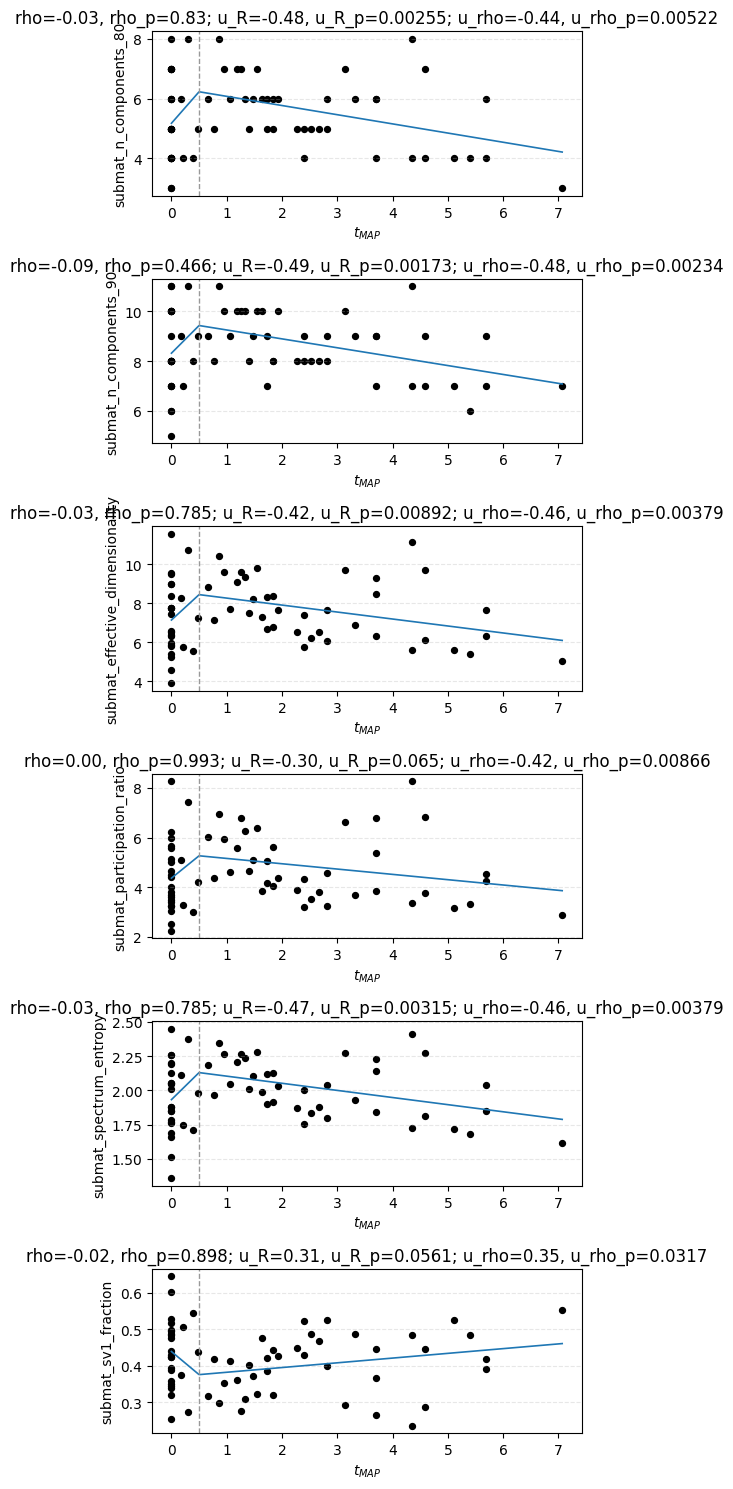

In [35]:
# SEARCH_TAG: SEGMENTED_FULLDATA_CHECK_DMS_SUBMAT
# Complementary full-dataset analysis (avoids conditioning on t_MAP partitions):
# Spearman + segmented regression vs t_MAP with knot at 1.0.
from scipy.stats import spearmanr, pearsonr

SEGMENT_KNOT_TMAP = 0.5

if 'segmented_regression_on_tmap' not in globals():
    from scipy.stats import t as student_t
    def segmented_regression_on_tmap(x_tmap, y_feature, knot=1.0):
        x = np.asarray(x_tmap, dtype=float)
        y = np.asarray(y_feature, dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        out = {
            'n': int(len(x)),
            'knot': float(knot),
            'slope_low': np.nan,
            'slope_low_p': np.nan,
            'slope_high': np.nan,
            'slope_high_p': np.nan,
            'slope_change': np.nan,
            'slope_change_p': np.nan,
            'r2': np.nan,
            'y_hat': np.full(len(x), np.nan),
            'x_used': x,
            'y_used': y,
        }

        if len(x) < 6 or np.unique(x).size < 3:
            return out

        h = np.clip(x - float(knot), 0.0, None)
        X = np.column_stack([np.ones(len(x)), x, h])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta

        n = len(x)
        p = X.shape[1]
        df_resid = n - p
        if df_resid <= 0:
            return out

        resid = y - y_hat
        rss = float(np.sum(resid ** 2))
        tss = float(np.sum((y - y.mean()) ** 2))
        r2 = float(1.0 - rss / tss) if tss > 0 else np.nan

        sigma2 = rss / df_resid if df_resid > 0 else np.nan
        XtX_inv = np.linalg.pinv(X.T @ X)
        cov = sigma2 * XtX_inv if np.isfinite(sigma2) else np.full_like(XtX_inv, np.nan)

        b0, b1, b2 = beta
        slope_low = float(b1)
        slope_high = float(b1 + b2)

        var_low = float(cov[1, 1]) if np.isfinite(cov[1, 1]) else np.nan
        var_change = float(cov[2, 2]) if np.isfinite(cov[2, 2]) else np.nan
        var_high = float(cov[1, 1] + cov[2, 2] + 2.0 * cov[1, 2]) if np.isfinite(cov[1, 2]) else np.nan

        def _t_p(value, var, df):
            if not np.isfinite(value) or not np.isfinite(var) or var <= 0 or df <= 0:
                return np.nan, np.nan
            se = np.sqrt(var)
            t_stat = value / se
            p_val = 2.0 * student_t.sf(np.abs(t_stat), df=df)
            return float(t_stat), float(p_val)

        _, p_low = _t_p(slope_low, var_low, df_resid)
        _, p_high = _t_p(slope_high, var_high, df_resid)
        _, p_change = _t_p(float(b2), var_change, df_resid)

        out.update(
            {
                'slope_low': slope_low,
                'slope_low_p': p_low,
                'slope_high': slope_high,
                'slope_high_p': p_high,
                'slope_change': float(b2),
                'slope_change_p': p_change,
                'r2': r2,
                'y_hat': y_hat,
                'x_used': x,
                'y_used': y,
            }
        )
        return out

if 'dms_subdim_df' not in globals():
    raise RuntimeError('Run Experiment 7 first (requires dms_subdim_df).')

if 'dim_features' not in globals():
    dim_features = [
        'submat_n_components_80',
        'submat_n_components_90',
        'submat_effective_dimensionality',
        'submat_participation_ratio',
        'submat_spectrum_entropy',
        'submat_sv1_fraction',
    ]

rows = []
fit_cache = {}
for feat in dim_features:
    tmp = dms_subdim_df[['t_map', feat]].copy().dropna()
    if len(tmp) < 5:
        continue

    x = tmp['t_map'].to_numpy(dtype=float)
    y = tmp[feat].to_numpy(dtype=float)

    if np.unique(x).size < 3 or np.unique(y).size < 2:
        continue

    spearman_rho, spearman_p = spearmanr(x, y)
    piece = segmented_regression_on_tmap(x, y, knot=SEGMENT_KNOT_TMAP)

    upper_mask = x >= SEGMENT_KNOT_TMAP
    n_upper = int(np.sum(upper_mask))
    upper_seg_pearson_r = np.nan
    upper_seg_pearson_p = np.nan
    upper_seg_r2 = np.nan
    upper_seg_spearman_rho = np.nan
    upper_seg_spearman_p = np.nan

    if n_upper >= 3:
        x_upper = x[upper_mask]
        y_upper = y[upper_mask]
        if np.unique(x_upper).size >= 2 and np.unique(y_upper).size >= 2:
            upper_seg_pearson_r, upper_seg_pearson_p = pearsonr(x_upper, y_upper)
            upper_seg_r2 = float(upper_seg_pearson_r ** 2)
            upper_seg_spearman_rho, upper_seg_spearman_p = spearmanr(x_upper, y_upper)

    rows.append(
        {
            'feature': feat,
            'n_domains': int(piece['n']),
            'rho': float(spearman_rho),
            'rho_p': float(spearman_p),
            'seg_knot_tmap': float(piece['knot']),
            'seg_r2': float(piece['r2']),
            'seg_slope_low': float(piece['slope_low']),
            'seg_slope_low_p': float(piece['slope_low_p']),
            'seg_slope_high': float(piece['slope_high']),
            'seg_slope_high_p': float(piece['slope_high_p']),
            'seg_slope_change': float(piece['slope_change']),
            'seg_slope_change_p': float(piece['slope_change_p']),
            'upper_seg_n': int(n_upper),
            'u_R': float(upper_seg_pearson_r),
            'u_R_p': float(upper_seg_pearson_p),
            'u_R2': float(upper_seg_r2),
            'u_rho': float(upper_seg_spearman_rho),
            'u_rho_p': float(upper_seg_spearman_p),
        }
    )
    fit_cache[feat] = piece

submat_segmented_df = pd.DataFrame(rows)
if len(submat_segmented_df) > 0:
    submat_segmented_df = submat_segmented_df.sort_values('rho', key=np.abs, ascending=False).reset_index(drop=True)

print('Complementary full-dataset check (no partition conditioning):')
print('Spearman on full data + segmented regression y(feature) ~ t_MAP with knot at 1.0.')
display(submat_segmented_df)

# Plot all features with segmented fit overlay.
plot_features = [f for f in dim_features if f in fit_cache]
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.2, 2.5 * max(1, len(plot_features))), squeeze=False)

if len(plot_features) == 0:
    axes[0, 0].text(0.5, 0.5, 'No features with sufficient data', ha='center', va='center')
    axes[0, 0].set_axis_off()
else:
    for ax, feat in zip(axes.ravel(), plot_features):
        piece = fit_cache[feat]
        x = piece['x_used']
        y = piece['y_used']

        ax.scatter(x, y, c='black', s=18)

        x_line = np.linspace(np.min(x), np.max(x), 300)
        h_line = np.clip(x_line - SEGMENT_KNOT_TMAP, 0.0, None)

        X = np.column_stack([np.ones(len(x)), x, np.clip(x - SEGMENT_KNOT_TMAP, 0.0, None)])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_line = beta[0] + beta[1] * x_line + beta[2] * h_line

        ax.plot(x_line, y_line, color='tab:blue', lw=1.2)
        ax.axvline(SEGMENT_KNOT_TMAP, color='0.6', lw=1, ls='--')

        row = submat_segmented_df.loc[submat_segmented_df['feature'] == feat].iloc[0]
        ax.set_xlabel(r'$t_{MAP}$')
        ax.set_ylabel(feat)
        ax.set_title(
            f"rho={row['rho']:.2f}, rho_p={row['rho_p']:.3g}; "
            f"u_R={row['u_R']:.2f}, u_R_p={row['u_R_p']:.3g}; "
            f"u_rho={row['u_rho']:.2f}, u_rho_p={row['u_rho_p']:.3g}"
        )
        ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


Permutation-significant subset: 31 domains (alpha=0.05, p-column=p_value).
Spearman on full subset + segmented regression y(feature) ~ t_MAP with knot at SEGMENT_KNOT_TMAP.


,feature,n_domains,rho,rho_p,seg_knot_tmap,seg_r2,seg_slope_low,seg_slope_low_p,seg_slope_high,seg_slope_high_p,seg_slope_change,seg_slope_change_p,upper_seg_n,u_R,u_R_p,u_R2,u_rho,u_rho_p
0,submat_n_components_90,31,-0.511674,0.003259,0.5,0.274926,1.955878,1.414124e-26,-0.409333,0.002937,-2.365211,1.741945e-15,31,-0.524334,0.002463,0.274926,-0.511674,0.003259
1,submat_n_components_80,31,-0.445935,0.011925,0.5,0.226603,1.269728,4.564726e-21,-0.371873,0.007837,-1.641601,2.525124e-11,31,-0.476028,0.006791,0.226603,-0.445935,0.011925
2,submat_effective_dimensionality,31,-0.434309,0.014635,0.5,0.162580,1.736175,3.199176e-21,-0.408483,0.027147,-2.144658,5.226034e-11,31,-0.403212,0.024501,0.162580,-0.434309,0.014635
3,submat_spectrum_entropy,31,-0.434309,0.014635,0.5,0.202073,0.452773,1.072792e-29,-0.059724,0.012696,-0.512497,1.200858e-17,31,-0.449525,0.011179,0.202073,-0.434309,0.014635
4,submat_participation_ratio,31,-0.394551,0.028058,0.5,0.083091,1.089841,4.339280e-17,-0.250950,0.122407,-1.340791,8.907198e-08,31,-0.288255,0.115818,0.083091,-0.394551,0.028058
5,submat_sv1_fraction,31,0.299092,0.102153,0.5,0.087819,0.088208,3.178881e-20,0.015919,0.111808,-0.072288,9.111372e-07,31,0.296342,0.105500,0.087819,0.299092,0.102153


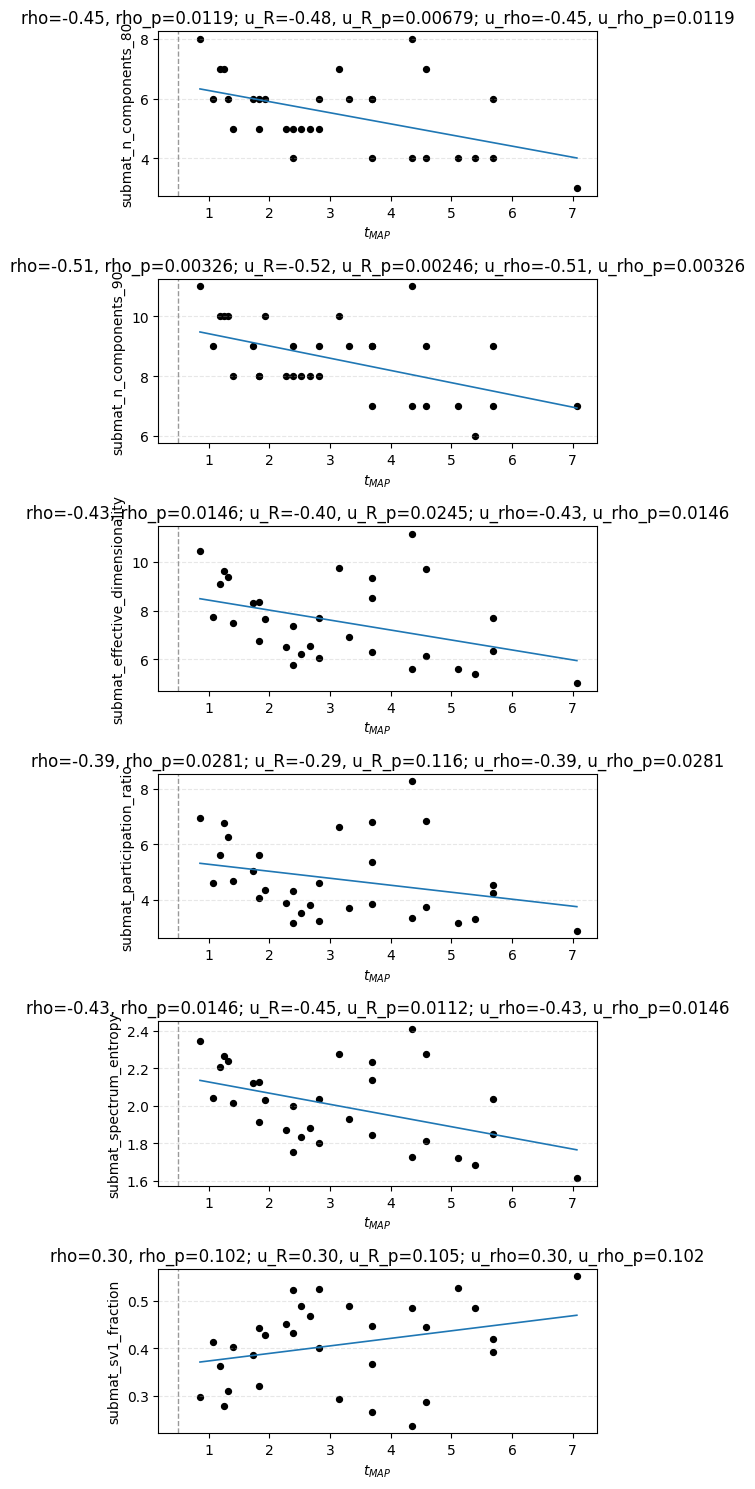

In [36]:
# SEARCH_TAG: SEGMENTED_FULLDATA_CHECK_DMS_SUBMAT_PERM_SIGNIFICANT
# Repeat the same Spearman + segmented regression analysis, restricted to
# landscapes significantly different from permutation background.
from scipy.stats import spearmanr, pearsonr

PERM_SIG_ALPHA = 0.05

if 'dms_subdim_df' not in globals():
    raise RuntimeError('Run Experiment 7 first (requires dms_subdim_df).')
if 'all_perm_results_df' not in globals():
    raise RuntimeError('Run the all-domain permutation testing cell first (requires all_perm_results_df).')
if 'segmented_regression_on_tmap' not in globals():
    raise RuntimeError('Run the full-data segmented regression cell first (defines segmented_regression_on_tmap).')

perm_df = all_perm_results_df.copy()
if 'p_value' in perm_df.columns:
    p_col = 'p_value'
elif 'p_empirical_two_sided' in perm_df.columns:
    p_col = 'p_empirical_two_sided'
else:
    raise RuntimeError('Permutation results need p_value or p_empirical_two_sided column.')

if 'status' in perm_df.columns:
    perm_df = perm_df.loc[perm_df['status'] == 'ok'].copy()

perm_df = perm_df.loc[np.isfinite(perm_df[p_col].to_numpy(dtype=float))].copy()
sig_perm_df = perm_df.loc[perm_df[p_col].to_numpy(dtype=float) < PERM_SIG_ALPHA].copy()
sig_files = set(sig_perm_df['file'].astype(str).tolist())

if len(sig_files) == 0:
    print(f'No permutation-significant systems at alpha={PERM_SIG_ALPHA:.3g}.')
    submat_segmented_sig_df = pd.DataFrame()
else:
    sig_subdim_df = dms_subdim_df.loc[dms_subdim_df['file'].astype(str).isin(sig_files)].copy()

    if 'dim_features' not in globals():
        dim_features = [
            'submat_n_components_80',
            'submat_n_components_90',
            'submat_effective_dimensionality',
            'submat_participation_ratio',
            'submat_spectrum_entropy',
            'submat_sv1_fraction',
        ]

    rows = []
    fit_cache_sig = {}

    for feat in dim_features:
        tmp = sig_subdim_df[['t_map', feat]].copy().dropna()
        if len(tmp) < 5:
            continue

        x = tmp['t_map'].to_numpy(dtype=float)
        y = tmp[feat].to_numpy(dtype=float)

        if np.unique(x).size < 3 or np.unique(y).size < 2:
            continue

        spearman_rho, spearman_p = spearmanr(x, y)
        piece = segmented_regression_on_tmap(x, y, knot=SEGMENT_KNOT_TMAP)

        upper_mask = x >= SEGMENT_KNOT_TMAP
        n_upper = int(np.sum(upper_mask))
        upper_seg_pearson_r = np.nan
        upper_seg_pearson_p = np.nan
        upper_seg_r2 = np.nan
        upper_seg_spearman_rho = np.nan
        upper_seg_spearman_p = np.nan

        if n_upper >= 3:
            x_upper = x[upper_mask]
            y_upper = y[upper_mask]
            if np.unique(x_upper).size >= 2 and np.unique(y_upper).size >= 2:
                upper_seg_pearson_r, upper_seg_pearson_p = pearsonr(x_upper, y_upper)
                upper_seg_r2 = float(upper_seg_pearson_r ** 2)
                upper_seg_spearman_rho, upper_seg_spearman_p = spearmanr(x_upper, y_upper)

        rows.append(
            {
                'feature': feat,
                'n_domains': int(piece['n']),
                'rho': float(spearman_rho),
                'rho_p': float(spearman_p),
                'seg_knot_tmap': float(piece['knot']),
                'seg_r2': float(piece['r2']),
                'seg_slope_low': float(piece['slope_low']),
                'seg_slope_low_p': float(piece['slope_low_p']),
                'seg_slope_high': float(piece['slope_high']),
                'seg_slope_high_p': float(piece['slope_high_p']),
                'seg_slope_change': float(piece['slope_change']),
                'seg_slope_change_p': float(piece['slope_change_p']),
                'upper_seg_n': int(n_upper),
                'u_R': float(upper_seg_pearson_r),
                'u_R_p': float(upper_seg_pearson_p),
                'u_R2': float(upper_seg_r2),
                'u_rho': float(upper_seg_spearman_rho),
                'u_rho_p': float(upper_seg_spearman_p),
            }
        )
        fit_cache_sig[feat] = piece

    submat_segmented_sig_df = pd.DataFrame(rows)
    if len(submat_segmented_sig_df) > 0:
        submat_segmented_sig_df = submat_segmented_sig_df.sort_values('rho', key=np.abs, ascending=False).reset_index(drop=True)

    print(
        f'Permutation-significant subset: {len(sig_subdim_df)} domains '
        f'(alpha={PERM_SIG_ALPHA:.3g}, p-column={p_col}).'
    )
    print('Spearman on full subset + segmented regression y(feature) ~ t_MAP with knot at SEGMENT_KNOT_TMAP.')
    display(submat_segmented_sig_df)

    plot_features = [f for f in dim_features if f in fit_cache_sig]
    fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.2, 2.5 * max(1, len(plot_features))), squeeze=False)

    if len(plot_features) == 0:
        axes[0, 0].text(0.5, 0.5, 'No features with sufficient data in significant subset', ha='center', va='center')
        axes[0, 0].set_axis_off()
    else:
        for ax, feat in zip(axes.ravel(), plot_features):
            piece = fit_cache_sig[feat]
            x = piece['x_used']
            y = piece['y_used']

            ax.scatter(x, y, c='black', s=18)

            x_line = np.linspace(np.min(x), np.max(x), 300)
            h_line = np.clip(x_line - SEGMENT_KNOT_TMAP, 0.0, None)

            X = np.column_stack([np.ones(len(x)), x, np.clip(x - SEGMENT_KNOT_TMAP, 0.0, None)])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            y_line = beta[0] + beta[1] * x_line + beta[2] * h_line

            ax.plot(x_line, y_line, color='tab:blue', lw=1.2)
            ax.axvline(SEGMENT_KNOT_TMAP, color='0.6', lw=1, ls='--')

            row = submat_segmented_sig_df.loc[submat_segmented_sig_df['feature'] == feat].iloc[0]
            ax.set_xlabel(r'$t_{MAP}$')
            ax.set_ylabel(feat)
            ax.set_title(
                f"rho={row['rho']:.2f}, rho_p={row['rho_p']:.3g}; "
                f"u_R={row['u_R']:.2f}, u_R_p={row['u_R_p']:.3g}; "
                f"u_rho={row['u_rho']:.2f}, u_rho_p={row['u_rho_p']:.3g}"
            )
            ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()



In [39]:
# SEARCH_TAG: LEFT_SV_PREREQ_HELPERS
# Minimal prerequisite helpers for LEFT_SV_STRUCTURAL_CLUSTERING and LEFT_SV_DOMAIN_VIS_AMFR_4G3O.
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests

PDB_AA3_TO_1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'MSE': 'M', 'SEC': 'U', 'PYL': 'O',
}


def extract_pdb_id_from_file(file_name):
    stem = Path(str(file_name)).stem
    token = stem.split('_')[-1].strip().upper()
    m = re.search(r'([0-9][A-Z0-9]{3})$', token)
    if m:
        return m.group(1)
    if len(token) >= 4:
        return token[-4:]
    raise ValueError(f'Cannot parse PDB id from file name: {file_name}')


def fetch_pdb_text(pdb_id, cache_dir=None, timeout=30):
    pdb_id = str(pdb_id).upper()

    if cache_dir is None:
        cache_dir = globals().get('PDB_CACHE_DIR', Path('../data_files/pdb_cache'))
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_candidates = [
        cache_dir / f'{pdb_id}.pdb',
        cache_dir / f'{pdb_id.lower()}.pdb',
        cache_dir / f'pdb{pdb_id.lower()}.ent',
    ]

    for p in cache_candidates:
        if p.exists():
            return p.read_text(), str(p)

    urls = [
        f'https://files.rcsb.org/download/{pdb_id}.pdb',
        f'https://files.rcsb.org/view/{pdb_id}.pdb',
    ]

    last_err = None
    for url in urls:
        try:
            r = requests.get(url, timeout=timeout)
            if r.status_code == 200 and ('ATOM' in r.text or 'MODEL' in r.text):
                out_path = cache_dir / f'{pdb_id}.pdb'
                out_path.write_text(r.text)
                return r.text, str(out_path)
        except Exception as exc:
            last_err = exc

    raise FileNotFoundError(f'Unable to retrieve PDB {pdb_id}. Last error: {last_err}')


def extract_main_chain_ensemble(pdb_text):
    # Parse CA coordinates by model/chain/residue.
    models = defaultdict(lambda: defaultdict(dict))
    model_id = 1

    for line in str(pdb_text).splitlines():
        rec = line[:6].strip()
        if rec == 'MODEL':
            model_raw = line[10:14].strip()
            try:
                model_id = int(model_raw)
            except Exception:
                model_id = 1
            continue

        if rec != 'ATOM':
            continue

        atom_name = line[12:16].strip()
        if atom_name != 'CA':
            continue

        altloc = line[16].strip()
        if altloc not in ('', 'A', '1'):
            continue

        chain = line[21].strip() or 'A'
        resname = line[17:20].strip().upper()
        try:
            resseq = int(line[22:26])
        except Exception:
            continue
        icode = line[26].strip()

        try:
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
        except Exception:
            continue

        key = (resseq, icode, resname)
        if key not in models[model_id][chain]:
            models[model_id][chain][key] = (x, y, z)

    if len(models) == 0:
        raise ValueError('No CA atoms parsed from PDB text.')

    model_ids = sorted(models.keys())
    first_model = model_ids[0]

    # Main chain = chain with most CA residues in first model.
    chain_sizes = {ch: len(res_map) for ch, res_map in models[first_model].items()}
    if len(chain_sizes) == 0:
        raise ValueError('No chains found in first model.')
    main_chain = sorted(chain_sizes.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

    first_keys = list(models[first_model][main_chain].keys())
    common_keys = [
        key for key in first_keys
        if all(main_chain in models[mid] and key in models[mid][main_chain] for mid in model_ids)
    ]
    if len(common_keys) == 0:
        raise ValueError('No common CA residues across ensemble models for selected main chain.')

    coords_models = []
    valid_model_ids = []
    for mid in model_ids:
        if main_chain not in models[mid]:
            continue
        if not all(key in models[mid][main_chain] for key in common_keys):
            continue
        arr = np.array([models[mid][main_chain][key] for key in common_keys], dtype=float)
        if arr.shape[0] == len(common_keys):
            coords_models.append(arr)
            valid_model_ids.append(mid)

    if len(coords_models) == 0:
        raise ValueError('No complete model found after enforcing common-residue set.')

    residue_rows = []
    seq_chars = []
    for i, (resseq, icode, resname) in enumerate(common_keys):
        aa = PDB_AA3_TO_1.get(resname, 'X')
        residue_rows.append({
            'position': int(i),
            'chain': str(main_chain),
            'resseq': int(resseq),
            'icode': str(icode),
            'resname': str(resname),
            'aa': aa,
        })
        seq_chars.append(aa)

    residue_df = pd.DataFrame(residue_rows)
    structure_seq = ''.join(seq_chars)

    return residue_df, coords_models, valid_model_ids, str(main_chain), structure_seq


def align_dms_to_structure_positions(wt_seq, structure_seq):
    # Global alignment (Needleman-Wunsch) and mapping: dms position (1-based) -> structure index (0-based).
    a = str(wt_seq)
    b = str(structure_seq)

    if len(a) == 0 or len(b) == 0:
        return {}, np.nan

    match = 2.0
    mismatch = -1.0
    gap = -2.0

    n, m = len(a), len(b)
    score = np.zeros((n + 1, m + 1), dtype=float)
    ptr = np.zeros((n + 1, m + 1), dtype=np.int8)  # 1=diag, 2=up, 3=left

    for i in range(1, n + 1):
        score[i, 0] = score[i - 1, 0] + gap
        ptr[i, 0] = 2
    for j in range(1, m + 1):
        score[0, j] = score[0, j - 1] + gap
        ptr[0, j] = 3

    for i in range(1, n + 1):
        ai = a[i - 1]
        for j in range(1, m + 1):
            bj = b[j - 1]
            s_diag = score[i - 1, j - 1] + (match if ai == bj else mismatch)
            s_up = score[i - 1, j] + gap
            s_left = score[i, j - 1] + gap
            best = s_diag
            move = 1
            if s_up > best:
                best = s_up
                move = 2
            if s_left > best:
                best = s_left
                move = 3
            score[i, j] = best
            ptr[i, j] = move

    # Traceback
    i, j = n, m
    aln_a = []
    aln_b = []
    while i > 0 or j > 0:
        move = ptr[i, j] if (i >= 0 and j >= 0) else 0
        if i > 0 and j > 0 and move == 1:
            aln_a.append(a[i - 1]); aln_b.append(b[j - 1]); i -= 1; j -= 1
        elif i > 0 and (j == 0 or move == 2):
            aln_a.append(a[i - 1]); aln_b.append('-'); i -= 1
        else:
            aln_a.append('-'); aln_b.append(b[j - 1]); j -= 1

    aln_a = aln_a[::-1]
    aln_b = aln_b[::-1]

    mapping = {}
    i_dms = -1
    i_struct = -1
    n_match = 0
    n_pairs = 0

    for ca, cb in zip(aln_a, aln_b):
        if ca != '-':
            i_dms += 1
        if cb != '-':
            i_struct += 1

        if ca != '-' and cb != '-':
            # DMS positions are 1-based in mutation annotations.
            mapping[int(i_dms + 1)] = int(i_struct)
            n_pairs += 1
            if ca == cb:
                n_match += 1

    seq_identity = float(n_match / n_pairs) if n_pairs > 0 else np.nan
    return mapping, seq_identity



Left-SV structural clustering:   0%|          | 0/64 [00:00<?, ?it/s]

Domains processed: 64
Domains with successful clustering run: 64


,dataset,t_map,status,n_positions_submat,n_positions_mapped,n_axes_tested,n_axes_clustered_p05,frac_axes_clustered_p05,mean_axis_cluster_z,n_axis_pairs_separated_p05,frac_axis_pairs_separated_p05,mean_pair_sep_z,error
0,RL20-AQUAE,7.068302e+00,ok,59,59,3,3,1.000000,-3.402934,0,0.0,-6.497480,
1,SR43C-ARATH,5.693530e+00,ok,48,48,3,2,0.666667,-2.747780,0,0.0,-4.805082,
2,TCRG1-MOUSE,5.693530e+00,ok,34,34,3,2,0.666667,-1.524900,0,0.0,-2.973977,
3,MAFG-MOUSE,5.393842e+00,ok,41,41,3,3,1.000000,-2.492430,0,0.0,-5.352048,
4,VG08-BPP22,5.109929e+00,ok,40,40,3,2,0.666667,-2.044302,0,0.0,-3.781742,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,CBPA2-HUMAN,1.000000e-10,ok,72,72,3,3,1.000000,-3.542173,0,0.0,-6.016925,
60,BBC1-YEAST,1.000000e-10,ok,64,64,3,0,0.000000,0.222104,0,0.0,-0.325446,
61,ILF3-HUMAN,1.000000e-10,ok,71,71,3,3,1.000000,-3.314344,0,0.0,-6.251352,
62,RS15-GEOSE,1.000000e-10,ok,63,63,3,2,0.666667,-1.668809,0,0.0,-3.162755,


,dataset,axis,explained_power_fraction,n_positions_selected,observed_mean_pair_dist,null_mean_pair_dist,z_vs_null,p_cluster_one_sided
0,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,0.388723,12,10.419717,12.380900,-2.082219,0.019934
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,2,0.200719,12,12.356364,12.497169,-0.137763,0.438538
2,AMFR_HUMAN_Tsuboyama_2023_4G3O,3,0.105236,12,10.916372,12.438310,-1.535148,0.089701
3,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,0.425863,18,11.133127,14.877749,-4.347393,0.003322
4,ARGR_ECOLI_Tsuboyama_2023_1AOY,2,0.231243,18,14.698931,14.818373,-0.128969,0.435216
...,...,...,...,...,...,...,...,...
187,YAIA_ECOLI_Tsuboyama_2023_2KVT,2,0.164073,13,13.822218,15.189232,-0.888023,0.192691
188,YAIA_ECOLI_Tsuboyama_2023_2KVT,3,0.138642,13,11.467314,15.280371,-2.234146,0.009967
189,YNZC_BACSU_Tsuboyama_2023_2JVD,1,0.450261,10,10.620824,13.083105,-1.452592,0.069767
190,YNZC_BACSU_Tsuboyama_2023_2JVD,2,0.192635,10,11.652871,12.875877,-0.744488,0.245847


,dataset,axis_a,axis_b,observed_cross_dist,null_mean_cross_dist,z_sep_vs_null,p_separation_one_sided
0,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,2,11.108774,12.422852,-2.311828,0.980066
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,1,3,10.824075,12.455787,-2.813922,1.000000
2,AMFR_HUMAN_Tsuboyama_2023_4G3O,2,3,11.086760,12.457838,-2.404406,0.993355
3,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,2,12.700108,14.812093,-3.658639,1.000000
4,ARGR_ECOLI_Tsuboyama_2023_1AOY,1,3,13.299425,14.777504,-2.741829,1.000000
...,...,...,...,...,...,...,...
187,YAIA_ECOLI_Tsuboyama_2023_2KVT,1,3,11.278327,15.094541,-4.016319,1.000000
188,YAIA_ECOLI_Tsuboyama_2023_2KVT,2,3,12.365327,15.250322,-3.016207,1.000000
189,YNZC_BACSU_Tsuboyama_2023_2JVD,1,2,10.332653,12.939731,-2.927655,1.000000
190,YNZC_BACSU_Tsuboyama_2023_2JVD,1,3,11.115852,12.972354,-1.980983,0.986711


Association with t_MAP (domain level):


,feature,pearson_r,pearson_p,spearman_rho,spearman_p,slope,slope_p,n_domains
0,median_pair_sep_p,0.199845,0.113360,0.158647,0.210531,2.407912,0.113360,64
1,n_axis_pairs_separated_p05,-0.115300,0.364276,-0.149308,0.238982,-1.698259,0.364276,64
2,frac_axis_pairs_separated_p05,-0.115300,0.364276,-0.149308,0.238982,-5.094776,0.364276,64
3,mean_pair_sep_z,-0.222754,0.076858,-0.136908,0.280693,-0.254450,0.076858,64
4,n_axes_clustered_p05,0.156854,0.215797,0.117562,0.354874,0.296269,0.215797,64
5,frac_axes_clustered_p05,0.156854,0.215797,0.117562,0.354874,0.888807,0.215797,64
6,median_axis_cluster_p,-0.192547,0.127429,-0.079636,0.531625,-2.395997,0.127429,64
7,mean_axis_cluster_z,-0.136819,0.281009,-0.046483,0.715312,-0.278539,0.281009,64


Association with substitution-matrix effective dimensionality:


,feature,target,pearson_r,pearson_p,spearman_rho,spearman_p,n_domains
0,mean_pair_sep_z,submat_n_components_90,0.570452,8.605695e-07,0.613267,7.150926e-08,64
1,mean_axis_cluster_z,submat_n_components_90,0.553911,2.054174e-06,0.575074,6.691194e-07,64
2,n_axes_clustered_p05,submat_n_components_90,-0.535862,5.039885e-06,-0.563128,1.272349e-06,64
3,frac_axes_clustered_p05,submat_n_components_90,-0.535862,5.039885e-06,-0.563128,1.272349e-06,64
4,mean_pair_sep_z,submat_effective_dimensionality,0.509715,1.693263e-05,0.542537,3.638348e-06,64
5,mean_axis_cluster_z,submat_effective_dimensionality,0.517687,1.182644e-05,0.528526,7.153563e-06,64
6,n_axes_clustered_p05,submat_effective_dimensionality,-0.503368,2.239015e-05,-0.508414,1.793887e-05,64
7,frac_axes_clustered_p05,submat_effective_dimensionality,-0.503368,2.239015e-05,-0.508414,1.793887e-05,64
8,n_axis_pairs_separated_p05,submat_n_components_90,0.131601,2.999352e-01,0.142921,2.599005e-01,64
9,n_axis_pairs_separated_p05,submat_effective_dimensionality,0.109950,3.871002e-01,0.112532,3.759776e-01,64


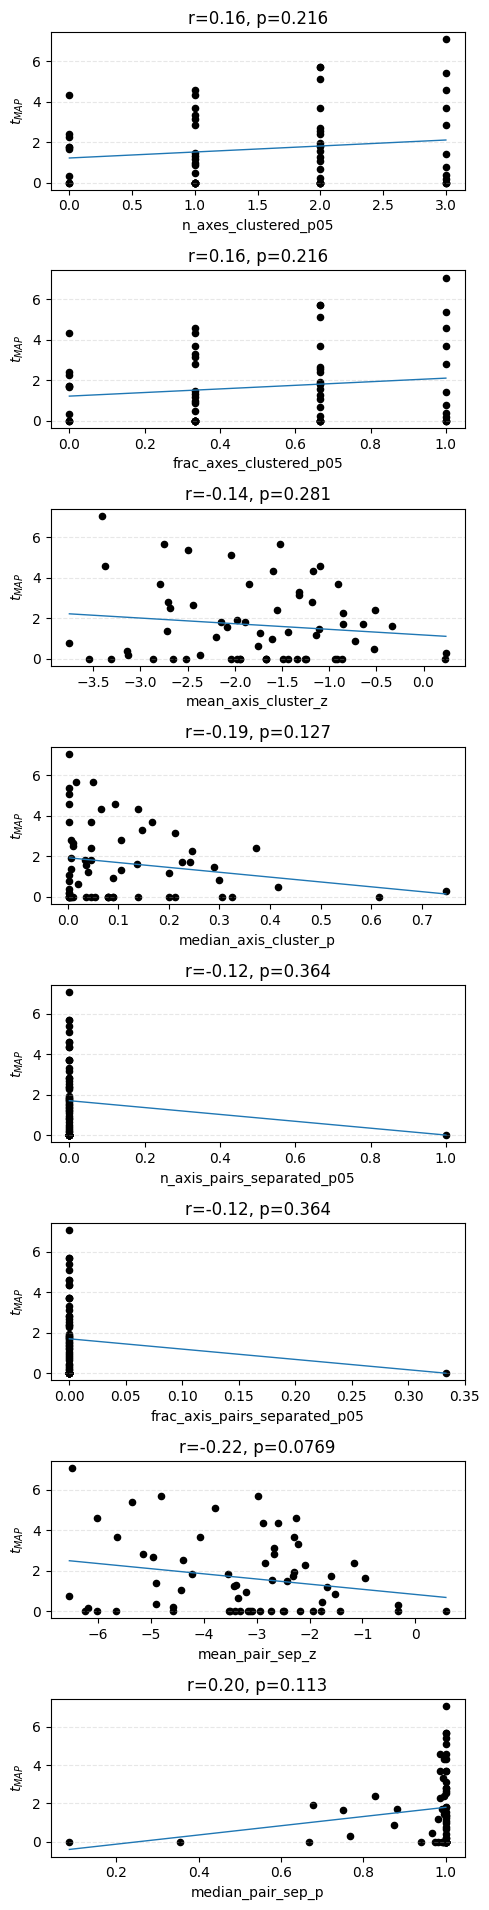

Axis-level correlation (t_MAP vs p_cluster_one_sided): Pearson r=-0.141, p=0.0503; Spearman rho=-0.066, p=0.366; n=192


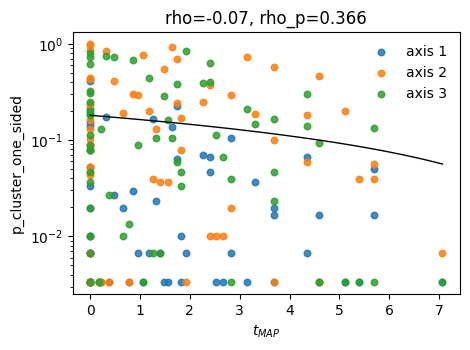

In [40]:
# SEARCH_TAG: LEFT_SV_STRUCTURAL_CLUSTERING
# Experiment 8: Are high-loading positions on each LEFT singular vector spatially clustered in 3D?
import re
import binascii
from itertools import combinations
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.stats import pearsonr, spearmanr, linregress

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
SV_TOP_K = 3
SV_TOP_LOADING_QUANTILE = 0.75   # top quartile by absolute loading
SV_NULL_REPS = 300               # increase for final runs
SV_MIN_ROWS_FOR_SVD = 8
SV_MIN_MEASURED_PER_ROW = 5
SV_RANDOM_SEED = 2026

AA20_SV = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_SV = re.compile(r'([A-Z])([0-9]+)([A-Z])')


def _parse_single_mutant_token_sv(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None

    m = MUT_TOKEN_RE_SV.fullmatch(tokens[0])
    if m is None:
        return None

    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa


def _extract_single_mutation_table_sv(domain_df):
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_sv(getattr(row, 'mutant', ''))
        if parsed is None:
            continue

        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_SV:
            continue

        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue

        rows.append(
            {
                'position': int(position),
                'wt_aa': wt_aa,
                'mut_aa': mut_aa,
                'DMS_score': score,
            }
        )

    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])

    mut_df = pd.DataFrame(rows)
    mut_df = mut_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return mut_df


def _mean_pairwise_ca_distance(coords, indices):
    idx = np.asarray(sorted(set(indices)), dtype=int)
    if len(idx) < 2:
        return np.nan

    pts = coords[idx]
    d = squareform(pdist(pts))
    tri = np.triu_indices(len(idx), k=1)
    return float(np.mean(d[tri]))


def _mean_cross_ca_distance(coords, idx_a, idx_b):
    a = np.asarray(sorted(set(idx_a)), dtype=int)
    b = np.asarray(sorted(set(idx_b)), dtype=int)
    if len(a) == 0 or len(b) == 0:
        return np.nan

    d = cdist(coords[a], coords[b])
    return float(np.mean(d))


def _build_wt_sequence_fallback(mut_df):
    if len(mut_df) == 0:
        raise ValueError('Cannot infer WT sequence from empty mutation table.')

    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    min_pos = int(wt_by_pos.index.min())
    max_pos = int(wt_by_pos.index.max())

    if min_pos != 1:
        raise ValueError('Fallback WT sequence inference requires positions starting at 1.')

    seq = ''.join(wt_by_pos.reindex(range(1, max_pos + 1)).fillna('X').tolist())
    return seq


def _compute_left_sv_structural_clustering_for_domain(file_name):
    out = {
        'file': file_name,
        'dataset': Path(file_name).stem,
        'status': 'ok',
        'error': '',
        'pdb_id': np.nan,
        'n_single_mutants': np.nan,
        'n_positions_submat': np.nan,
        'n_positions_mapped': np.nan,
        'sequence_alignment_identity': np.nan,
        'n_axes_tested': 0,
        'n_axes_clustered_p05': 0,
        'frac_axes_clustered_p05': np.nan,
        'mean_axis_cluster_z': np.nan,
        'median_axis_cluster_p': np.nan,
        'n_axis_pairs_tested': 0,
        'n_axis_pairs_separated_p05': 0,
        'frac_axis_pairs_separated_p05': np.nan,
        'mean_pair_sep_z': np.nan,
        'median_pair_sep_p': np.nan,
    }

    axis_rows = []
    pair_rows = []

    try:
        domain_df = load_domain_dataframe(file_name)
        mut_df = _extract_single_mutation_table_sv(domain_df)
        out['n_single_mutants'] = int(len(mut_df))

        if len(mut_df) == 0:
            raise ValueError('No usable single-mutation records.')

        submat_df = (
            mut_df
            .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
            .reindex(columns=AA20_SV)
            .sort_index()
        ).copy(deep=True)

        wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
        col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}

        # Build an explicit writable ndarray to avoid read-only assignment errors.
        arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)
        if not arr_all.flags.writeable:
            arr_all = arr_all.copy()

        # Mask per-position WT entries so we analyze non-WT substitutions.
        for r_i, pos in enumerate(submat_df.index.to_numpy()):
            wt = wt_by_pos.get(int(pos), None)
            c_i = col_to_idx.get(wt, None)
            if c_i is not None:
                arr_all[r_i, c_i] = np.nan

        measured_per_row = np.isfinite(arr_all).sum(axis=1)
        keep_mask = measured_per_row >= SV_MIN_MEASURED_PER_ROW

        kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
        arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

        if arr.shape[0] < SV_MIN_ROWS_FOR_SVD:
            raise ValueError(f'Insufficient rows after filtering: {arr.shape[0]} < {SV_MIN_ROWS_FOR_SVD}.')

        row_means = np.nanmean(arr, axis=1)
        nan_mask = ~np.isfinite(arr)
        if nan_mask.any():
            arr[nan_mask] = row_means[np.where(nan_mask)[0]]

        arr = arr - np.mean(arr, axis=1, keepdims=True)
        if not np.isfinite(arr).all() or np.allclose(arr, 0.0):
            raise ValueError('Centered substitution matrix is degenerate.')

        U, S, Vt = np.linalg.svd(arr, full_matrices=False)
        dms_positions = kept_positions.astype(int)
        out['n_positions_submat'] = int(len(dms_positions))

        out['pdb_id'] = extract_pdb_id_from_file(file_name)
        pdb_text, _ = fetch_pdb_text(out['pdb_id'])
        residue_df, coords_models, model_ids, main_chain, structure_seq = extract_main_chain_ensemble(pdb_text)

        if 'infer_wildtype_sequence' in globals():
            wt_seq = infer_wildtype_sequence(domain_df)
        else:
            wt_seq = _build_wt_sequence_fallback(mut_df)

        if 'align_dms_to_structure_positions' not in globals():
            raise ValueError('align_dms_to_structure_positions is not defined; run the reviewer-metrics setup cells first.')

        dms_to_struct_map, seq_ident = align_dms_to_structure_positions(wt_seq, structure_seq)
        out['sequence_alignment_identity'] = float(seq_ident)

        mapped_positions = [int(p) for p in dms_positions if int(p) in dms_to_struct_map]
        out['n_positions_mapped'] = int(len(mapped_positions))
        if len(mapped_positions) < SV_MIN_ROWS_FOR_SVD:
            raise ValueError('Too few mapped positions for clustering test.')

        coords = np.asarray(coords_models[0], dtype=float)
        mapped_pool = np.asarray(sorted({int(dms_to_struct_map[p]) for p in mapped_positions}), dtype=int)

        if len(mapped_pool) < SV_MIN_ROWS_FOR_SVD:
            raise ValueError('Too few unique mapped structure positions.')

        k_eff = int(min(SV_TOP_K, U.shape[1]))
        if k_eff < 1:
            raise ValueError('No usable singular vectors.')

        seed = SV_RANDOM_SEED + int(binascii.crc32(str(file_name).encode('utf-8')) % 1_000_000)
        rng = np.random.default_rng(seed)

        axis_sets = {}
        for axis_idx in range(k_eff):
            abs_load = np.abs(U[:, axis_idx])
            n_select = int(max(3, np.ceil((1.0 - SV_TOP_LOADING_QUANTILE) * len(abs_load))))
            top_idx = np.argsort(abs_load)[::-1][:n_select]

            top_positions = [int(dms_positions[i]) for i in top_idx if int(dms_positions[i]) in dms_to_struct_map]
            top_struct = sorted({int(dms_to_struct_map[p]) for p in top_positions})

            row_axis = {
                'file': file_name,
                'dataset': out['dataset'],
                'pdb_id': out['pdb_id'],
                'axis': int(axis_idx + 1),
                'singular_value': float(S[axis_idx]),
                'explained_power_fraction': float((S[axis_idx] ** 2) / np.sum(S ** 2)),
                'n_positions_selected': int(len(top_struct)),
                'observed_mean_pair_dist': np.nan,
                'null_mean_pair_dist': np.nan,
                'null_std_pair_dist': np.nan,
                'z_vs_null': np.nan,
                'p_cluster_one_sided': np.nan,
                'cluster_effect_ratio_obs_over_null': np.nan,
            }

            if len(top_struct) >= 3 and len(mapped_pool) >= len(top_struct):
                obs = _mean_pairwise_ca_distance(coords, top_struct)

                null_vals = []
                for _ in range(SV_NULL_REPS):
                    rand_idx = rng.choice(mapped_pool, size=len(top_struct), replace=False)
                    null_vals.append(_mean_pairwise_ca_distance(coords, rand_idx))

                null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
                if len(null_arr) > 0 and np.isfinite(obs):
                    null_mean = float(np.mean(null_arr))
                    null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
                    p_cluster = float((np.sum(null_arr <= obs) + 1) / (len(null_arr) + 1))
                    z_val = float((obs - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
                    ratio = float(obs / null_mean) if np.isfinite(null_mean) and null_mean != 0 else np.nan

                    row_axis.update(
                        {
                            'observed_mean_pair_dist': float(obs),
                            'null_mean_pair_dist': null_mean,
                            'null_std_pair_dist': null_std,
                            'z_vs_null': z_val,
                            'p_cluster_one_sided': p_cluster,
                            'cluster_effect_ratio_obs_over_null': ratio,
                        }
                    )
                    axis_sets[int(axis_idx + 1)] = top_struct

            axis_rows.append(row_axis)

        # Between-axis separation test: are high-loading sets from different axes farther apart than random?
        for ax_a, ax_b in combinations(sorted(axis_sets.keys()), 2):
            idx_a = axis_sets[ax_a]
            idx_b = axis_sets[ax_b]

            row_pair = {
                'file': file_name,
                'dataset': out['dataset'],
                'pdb_id': out['pdb_id'],
                'axis_a': int(ax_a),
                'axis_b': int(ax_b),
                'n_a': int(len(idx_a)),
                'n_b': int(len(idx_b)),
                'observed_cross_dist': np.nan,
                'null_mean_cross_dist': np.nan,
                'null_std_cross_dist': np.nan,
                'z_sep_vs_null': np.nan,
                'p_separation_one_sided': np.nan,
                'sep_effect_ratio_obs_over_null': np.nan,
            }

            if len(mapped_pool) >= (len(idx_a) + len(idx_b)):
                obs_cross = _mean_cross_ca_distance(coords, idx_a, idx_b)

                null_vals = []
                for _ in range(SV_NULL_REPS):
                    samp = rng.choice(mapped_pool, size=(len(idx_a) + len(idx_b)), replace=False)
                    ra = samp[:len(idx_a)]
                    rb = samp[len(idx_a):]
                    null_vals.append(_mean_cross_ca_distance(coords, ra, rb))

                null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
                if len(null_arr) > 0 and np.isfinite(obs_cross):
                    null_mean = float(np.mean(null_arr))
                    null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
                    p_sep = float((np.sum(null_arr >= obs_cross) + 1) / (len(null_arr) + 1))
                    z_sep = float((obs_cross - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
                    ratio = float(obs_cross / null_mean) if np.isfinite(null_mean) and null_mean != 0 else np.nan

                    row_pair.update(
                        {
                            'observed_cross_dist': float(obs_cross),
                            'null_mean_cross_dist': null_mean,
                            'null_std_cross_dist': null_std,
                            'z_sep_vs_null': z_sep,
                            'p_separation_one_sided': p_sep,
                            'sep_effect_ratio_obs_over_null': ratio,
                        }
                    )

            pair_rows.append(row_pair)

        axis_df = pd.DataFrame(axis_rows)
        pair_df = pd.DataFrame(pair_rows)

        valid_axis = axis_df.dropna(subset=['p_cluster_one_sided']) if len(axis_df) else pd.DataFrame()
        valid_pair = pair_df.dropna(subset=['p_separation_one_sided']) if len(pair_df) else pd.DataFrame()

        out['n_axes_tested'] = int(len(valid_axis))
        out['n_axes_clustered_p05'] = int((valid_axis['p_cluster_one_sided'] < 0.05).sum()) if len(valid_axis) else 0
        out['frac_axes_clustered_p05'] = float(out['n_axes_clustered_p05'] / out['n_axes_tested']) if out['n_axes_tested'] > 0 else np.nan
        out['mean_axis_cluster_z'] = float(valid_axis['z_vs_null'].mean()) if len(valid_axis) else np.nan
        out['median_axis_cluster_p'] = float(valid_axis['p_cluster_one_sided'].median()) if len(valid_axis) else np.nan

        out['n_axis_pairs_tested'] = int(len(valid_pair))
        out['n_axis_pairs_separated_p05'] = int((valid_pair['p_separation_one_sided'] < 0.05).sum()) if len(valid_pair) else 0
        out['frac_axis_pairs_separated_p05'] = (
            float(out['n_axis_pairs_separated_p05'] / out['n_axis_pairs_tested']) if out['n_axis_pairs_tested'] > 0 else np.nan
        )
        out['mean_pair_sep_z'] = float(valid_pair['z_sep_vs_null'].mean()) if len(valid_pair) else np.nan
        out['median_pair_sep_p'] = float(valid_pair['p_separation_one_sided'].median()) if len(valid_pair) else np.nan

    except Exception as exc:
        out['status'] = 'error'
        out['error'] = f"{type(exc).__name__}: {exc}"

    return out, axis_rows, pair_rows


domain_rows = []
axis_rows_all = []
pair_rows_all = []

for row in tqdm(dms_tmap_df.itertuples(index=False), total=len(dms_tmap_df), desc='Left-SV structural clustering'):
    domain_out, axis_rows, pair_rows = _compute_left_sv_structural_clustering_for_domain(row.file)
    domain_out['dataset'] = row.dataset
    domain_out['t_map'] = float(row.t)

    domain_rows.append(domain_out)
    axis_rows_all.extend(axis_rows)
    pair_rows_all.extend(pair_rows)

left_sv_domain_df = pd.DataFrame(domain_rows).sort_values('t_map', ascending=False).reset_index(drop=True)
left_sv_axis_df = pd.DataFrame(axis_rows_all)
left_sv_pair_df = pd.DataFrame(pair_rows_all)

print('Domains processed:', len(left_sv_domain_df))
print('Domains with successful clustering run:', int((left_sv_domain_df['status'] == 'ok').sum()))

display(
    left_sv_domain_df[
        [
            'dataset', 't_map', 'status', 'n_positions_submat', 'n_positions_mapped',
            'n_axes_tested', 'n_axes_clustered_p05', 'frac_axes_clustered_p05',
            'mean_axis_cluster_z', 'n_axis_pairs_separated_p05', 'frac_axis_pairs_separated_p05',
            'mean_pair_sep_z', 'error'
        ]
    ]
)

if len(left_sv_axis_df) > 0:
    axis_show = left_sv_axis_df.dropna(subset=['p_cluster_one_sided']).copy()
    axis_show = axis_show.sort_values(['dataset', 'axis']).reset_index(drop=True)
    display(
        axis_show[
            [
                'dataset', 'axis', 'explained_power_fraction', 'n_positions_selected',
                'observed_mean_pair_dist', 'null_mean_pair_dist', 'z_vs_null', 'p_cluster_one_sided'
            ]
        ]
    )

if len(left_sv_pair_df) > 0:
    pair_show = left_sv_pair_df.dropna(subset=['p_separation_one_sided']).copy()
    pair_show = pair_show.sort_values(['dataset', 'axis_a', 'axis_b']).reset_index(drop=True)
    display(
        pair_show[
            [
                'dataset', 'axis_a', 'axis_b', 'observed_cross_dist',
                'null_mean_cross_dist', 'z_sep_vs_null', 'p_separation_one_sided'
            ]
        ]
    )

# Domain-level associations to ruggedness (t_MAP) and, when available, effective dimensionality.
summary_features = [
    'n_axes_clustered_p05',
    'frac_axes_clustered_p05',
    'mean_axis_cluster_z',
    'median_axis_cluster_p',
    'n_axis_pairs_separated_p05',
    'frac_axis_pairs_separated_p05',
    'mean_pair_sep_z',
    'median_pair_sep_p',
]

assoc_rows_tmap = []
for feat in summary_features:
    tmp = left_sv_domain_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    rho, rho_p = spearmanr(x, y)
    lr = linregress(x, y)

    assoc_rows_tmap.append(
        {
            'feature': feat,
            'pearson_r': float(pear_r),
            'pearson_p': float(pear_p),
            'spearman_rho': float(rho),
            'spearman_p': float(rho_p),
            'slope': float(lr.slope),
            'slope_p': float(lr.pvalue),
            'n_domains': int(len(tmp)),
        }
    )

left_sv_assoc_tmap_df = pd.DataFrame(assoc_rows_tmap)
if len(left_sv_assoc_tmap_df) > 0:
    left_sv_assoc_tmap_df = left_sv_assoc_tmap_df.sort_values('spearman_rho', key=np.abs, ascending=False).reset_index(drop=True)

print('Association with t_MAP (domain level):')
display(left_sv_assoc_tmap_df)

if 'dms_subdim_df' in globals():
    merged = left_sv_domain_df.merge(
        dms_subdim_df[['file', 'submat_effective_dimensionality', 'submat_n_components_90']],
        on='file',
        how='left'
    )

    assoc_rows_dim = []
    for feat in ['n_axes_clustered_p05', 'frac_axes_clustered_p05', 'mean_axis_cluster_z', 'n_axis_pairs_separated_p05', 'mean_pair_sep_z']:
        for target in ['submat_effective_dimensionality', 'submat_n_components_90']:
            tmp = merged.dropna(subset=[feat, target]).copy()
            if len(tmp) < 5 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
                continue

            x = tmp[feat].to_numpy(dtype=float)
            y = tmp[target].to_numpy(dtype=float)

            pear_r, pear_p = pearsonr(x, y)
            rho, rho_p = spearmanr(x, y)

            assoc_rows_dim.append(
                {
                    'feature': feat,
                    'target': target,
                    'pearson_r': float(pear_r),
                    'pearson_p': float(pear_p),
                    'spearman_rho': float(rho),
                    'spearman_p': float(rho_p),
                    'n_domains': int(len(tmp)),
                }
            )

    left_sv_assoc_dim_df = pd.DataFrame(assoc_rows_dim)
    if len(left_sv_assoc_dim_df) > 0:
        left_sv_assoc_dim_df = left_sv_assoc_dim_df.sort_values('spearman_rho', key=np.abs, ascending=False).reset_index(drop=True)

    print('Association with substitution-matrix effective dimensionality:')
    display(left_sv_assoc_dim_df)

# Plot all summary-vs-ruggedness relationships in SI style (1 column by n rows).
plot_features = summary_features
fig, axes = plt.subplots(len(plot_features), 1, figsize=(5.0, 2.4 * len(plot_features)), squeeze=False)

for ax, feat in zip(axes.ravel(), plot_features):
    tmp = left_sv_domain_df.dropna(subset=['t_map', feat]).copy()
    if len(tmp) < 4 or np.unique(tmp[feat].to_numpy(dtype=float)).size < 2:
        ax.text(0.5, 0.5, f'{feat}: insufficient data', ha='center', va='center')
        ax.set_axis_off()
        continue

    x = tmp[feat].to_numpy(dtype=float)
    y = tmp['t_map'].to_numpy(dtype=float)
    lr = linregress(x, y)

    ax.scatter(x, y, c='black', s=20)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, lr.slope * x_line + lr.intercept, color='tab:blue', lw=1)

    ax.set_xlabel(feat)
    ax.set_ylabel(r'$t_{MAP}$')
    ax.set_title(f'r={lr.rvalue:.2f}, p={lr.pvalue:.3g}')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# Additional plot: axis-level p_cluster_one_sided vs domain t_MAP.
req_axis_cols = {'file', 'p_cluster_one_sided'}
req_domain_cols = {'file', 't_map'}

if req_axis_cols.issubset(set(left_sv_axis_df.columns)) and req_domain_cols.issubset(set(left_sv_domain_df.columns)):
    axis_corr_df = (
        left_sv_axis_df
        .merge(left_sv_domain_df[['file', 't_map']], on='file', how='left')
        .dropna(subset=['t_map', 'p_cluster_one_sided'])
        .copy()
    )
else:
    axis_corr_df = pd.DataFrame(columns=['file', 't_map', 'p_cluster_one_sided', 'axis'])

if len(axis_corr_df) >= 5 and np.unique(axis_corr_df['t_map'].to_numpy(float)).size >= 2:
    x = axis_corr_df['t_map'].to_numpy(dtype=float)
    y = axis_corr_df['p_cluster_one_sided'].to_numpy(dtype=float)

    pear_r, pear_p = pearsonr(x, y)
    rho, rho_p = spearmanr(x, y)

    print(
        f"Axis-level correlation (t_MAP vs p_cluster_one_sided): "
        f"Pearson r={pear_r:.3f}, p={pear_p:.3g}; Spearman rho={rho:.3f}, p={rho_p:.3g}; n={len(axis_corr_df)}"
    )

    plt.figure(figsize=(4.8, 3.6))

    if 'axis' in axis_corr_df.columns:
        for axis_id in sorted(axis_corr_df['axis'].dropna().unique()):
            sub = axis_corr_df.loc[axis_corr_df['axis'] == axis_id]
            plt.scatter(sub['t_map'], sub['p_cluster_one_sided'], s=22, alpha=0.85, label=f'axis {int(axis_id)}')
    else:
        plt.scatter(x, y, c='black', s=22)

    x_line = np.linspace(float(np.min(x)), float(np.max(x)), 100)
    slope, intercept = np.polyfit(x, y, 1)
    plt.plot(x_line, slope * x_line + intercept, color='black', lw=1)

    plt.xlabel(r'$t_{MAP}$')
    plt.ylabel('p_cluster_one_sided')
    plt.yscale('log')
    plt.title(f"rho={rho:.2f}, rho_p={rho_p:.3g}")
    if 'axis' in axis_corr_df.columns:
        plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print('Axis-level t_MAP vs p_cluster_one_sided plot: insufficient data.')



In [45]:
# SEARCH_TAG: LEFT_SV_DOMAIN_VIS_AMFR_4G3O
# Experiment 8b: Domain-specific LEFT-SV structural visualization
import re
import binascii
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from scipy.spatial.distance import pdist, squareform

TARGET_DOMAIN_FILE = 'RL20_AQUAE_Tsuboyama_2023_1GYZ.csv'
TARGET_TOP_K = 3
TARGET_TOP_LOADING_QUANTILE = 0.75
TARGET_NULL_REPS = 500
TARGET_MIN_MEASURED_PER_ROW = 5
TARGET_MIN_ROWS_FOR_SVD = 8
TARGET_RANDOM_SEED = 2026
OUTDIR = Path('../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes')
OUTDIR.mkdir(parents=True, exist_ok=True)

AA20_VIS = list('ACDEFGHIKLMNPQRSTVWY')
MUT_TOKEN_RE_VIS = re.compile(r'([A-Z])([0-9]+)([A-Z])')

def _parse_single_mutant_token_vis(mutant):
    tokens = [tok.strip() for tok in str(mutant).split(':') if tok.strip()]
    if len(tokens) != 1:
        return None
    m = MUT_TOKEN_RE_VIS.fullmatch(tokens[0])
    if m is None:
        return None
    wt_aa, pos_str, mut_aa = m.groups()
    return wt_aa, int(pos_str), mut_aa

def _extract_single_mutation_table_vis(domain_df):
    if '_extract_single_mutation_table_sv' in globals():
        return _extract_single_mutation_table_sv(domain_df)
    rows = []
    for row in domain_df.itertuples(index=False):
        parsed = _parse_single_mutant_token_vis(getattr(row, 'mutant', ''))
        if parsed is None:
            continue
        wt_aa, position, mut_aa = parsed
        if mut_aa not in AA20_VIS:
            continue
        score = float(getattr(row, 'DMS_score'))
        if not np.isfinite(score):
            continue
        rows.append({'position': int(position), 'wt_aa': wt_aa, 'mut_aa': mut_aa, 'DMS_score': score})
    if len(rows) == 0:
        return pd.DataFrame(columns=['position', 'wt_aa', 'mut_aa', 'DMS_score'])
    mut_df = pd.DataFrame(rows)
    mut_df = mut_df.groupby(['position', 'wt_aa', 'mut_aa'], as_index=False)['DMS_score'].mean()
    return mut_df

def _infer_wt_sequence_vis(mut_df):
    wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
    min_pos = int(wt_by_pos.index.min())
    max_pos = int(wt_by_pos.index.max())
    if min_pos != 1:
        raise ValueError('WT sequence fallback expects positions starting at 1.')
    return ''.join(wt_by_pos.reindex(range(1, max_pos + 1)).fillna('X').tolist())

def _mean_pairwise_ca_distance(coords, idx):
    idx = np.asarray(sorted(set(idx)), dtype=int)
    if len(idx) < 2:
        return np.nan
    pts = coords[idx]
    d = squareform(pdist(pts))
    tri = np.triu_indices(len(idx), k=1)
    return float(np.mean(d[tri]))

def _filter_to_first_model_main_chain_pdb(pdb_text_in, chain_id):
    out_lines = []
    has_model_records = False
    in_first_model = True
    for line in pdb_text_in.splitlines():
        rec = line[:6].strip()
        if rec == 'MODEL':
            has_model_records = True
            try:
                model_no = int(line[10:14].strip())
            except Exception:
                model_no = 1
            in_first_model = (model_no == 1)
            continue
        if rec == 'ENDMDL':
            if has_model_records and in_first_model:
                break
            continue
        if has_model_records and not in_first_model:
            continue
        if rec in {'ATOM', 'HETATM', 'TER'}:
            if len(line) < 22:
                continue
            line_chain = (line[21].strip() or '_')
            if line_chain != chain_id:
                continue
            out_lines.append(line)
    if len(out_lines) == 0:
        raise ValueError(f'No atoms found for selected chain {chain_id} in first model.')
    out_lines.append('END')
    return '\n'.join(out_lines) + '\n'

# ── Coolwarm colour mapping ──
_COOLWARM_CMAP = cm.get_cmap('coolwarm')

def _loading_to_rgb_hex(value, vmax):
    """Map a loading value to a coolwarm hex colour string for ChimeraX."""
    t = np.clip(value / vmax, -1.0, 1.0)
    # Map from [-1, 1] to [0, 1] for the colourmap
    cmap_val = (t + 1.0) / 2.0
    r, g, b, _ = _COOLWARM_CMAP(cmap_val)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

required = ['load_domain_dataframe', 'extract_pdb_id_from_file', 'fetch_pdb_text',
            'extract_main_chain_ensemble', 'align_dms_to_structure_positions']
missing_required = [name for name in required if name not in globals()]
if missing_required:
    raise RuntimeError(f'Run prerequisite reviewer cells first; missing symbols: {missing_required}')

if 'dms_tmap_df' in globals() and TARGET_DOMAIN_FILE in set(dms_tmap_df['file']):
    t_value = float(dms_tmap_df.loc[dms_tmap_df['file'] == TARGET_DOMAIN_FILE, 't'].iloc[0])
else:
    t_value = np.nan

# Build substitution matrix and LEFT singular vectors.
domain_df = load_domain_dataframe(TARGET_DOMAIN_FILE)
mut_df = _extract_single_mutation_table_vis(domain_df)
if len(mut_df) == 0:
    raise ValueError('No usable single-mutant records for target domain.')

submat_df = (
    mut_df
    .pivot_table(index='position', columns='mut_aa', values='DMS_score', aggfunc='mean')
    .reindex(columns=AA20_VIS)
    .sort_index()
).copy(deep=True)

wt_by_pos = mut_df.groupby('position')['wt_aa'].agg(lambda s: s.value_counts().idxmax())
col_to_idx = {aa: i for i, aa in enumerate(submat_df.columns)}
arr_all = np.array(submat_df.to_numpy(dtype=float, copy=True), dtype=float, copy=True)

for r_i, pos in enumerate(submat_df.index.to_numpy()):
    wt = wt_by_pos.get(int(pos), None)
    c_i = col_to_idx.get(wt, None)
    if c_i is not None:
        arr_all[r_i, c_i] = np.nan

measured_per_row = np.isfinite(arr_all).sum(axis=1)
keep_mask = measured_per_row >= TARGET_MIN_MEASURED_PER_ROW
kept_positions = submat_df.index.to_numpy(dtype=int)[keep_mask]
arr = np.array(arr_all[keep_mask], dtype=float, copy=True)

if arr.shape[0] < TARGET_MIN_ROWS_FOR_SVD:
    raise ValueError(f'Insufficient rows after filtering: {arr.shape[0]} < {TARGET_MIN_ROWS_FOR_SVD}.')

row_means = np.nanmean(arr, axis=1)
nan_mask = ~np.isfinite(arr)
if nan_mask.any():
    arr[nan_mask] = row_means[np.where(nan_mask)[0]]

arr = arr - np.mean(arr, axis=1, keepdims=True)
if not np.isfinite(arr).all() or np.allclose(arr, 0.0):
    raise ValueError('Centered substitution matrix is degenerate.')

U, S, Vt = np.linalg.svd(arr, full_matrices=False)
power = S**2
power_frac = power / np.sum(power)

# Map DMS positions to structure positions.
pdb_id = extract_pdb_id_from_file(TARGET_DOMAIN_FILE)
pdb_text, cache_path = fetch_pdb_text(pdb_id)
residue_df, coords_models, model_ids, main_chain, structure_seq = extract_main_chain_ensemble(pdb_text)
pdb_text_main_chain = _filter_to_first_model_main_chain_pdb(pdb_text, main_chain)
coords = np.asarray(coords_models[0], dtype=float)

if 'infer_wildtype_sequence' in globals():
    wt_seq = infer_wildtype_sequence(domain_df)
else:
    wt_seq = _infer_wt_sequence_vis(mut_df)

dms_to_struct_map, seq_ident = align_dms_to_structure_positions(wt_seq, structure_seq)

mapped_mask = np.array([int(p) in dms_to_struct_map for p in kept_positions], dtype=bool)
if mapped_mask.sum() < TARGET_MIN_ROWS_FOR_SVD:
    raise ValueError('Too few mapped positions for the target domain.')

mapped_dms_positions = kept_positions[mapped_mask]
mapped_struct_idx = np.array([int(dms_to_struct_map[int(p)]) for p in mapped_dms_positions], dtype=int)
U_map = U[mapped_mask, :]

# Aggregate duplicate structure mappings.
k_eff = int(min(TARGET_TOP_K, U_map.shape[1]))
unique_struct = np.array(sorted(set(mapped_struct_idx.tolist())), dtype=int)
loadings_by_axis = np.full((k_eff, len(residue_df)), np.nan, dtype=float)
top_mask_by_axis = np.zeros((k_eff, len(residue_df)), dtype=bool)
axis_stats_rows = []

seed = TARGET_RANDOM_SEED + int(binascii.crc32(TARGET_DOMAIN_FILE.encode('utf-8')) % 1_000_000)
rng = np.random.default_rng(seed)

for ax in range(k_eff):
    ser = pd.DataFrame({'struct_idx': mapped_struct_idx, 'loading': U_map[:, ax]}).groupby('struct_idx', as_index=False)['loading'].mean()
    struct_idx_axis = ser['struct_idx'].to_numpy(dtype=int)
    loading_axis = ser['loading'].to_numpy(dtype=float)
    loadings_by_axis[ax, struct_idx_axis] = loading_axis

    n_select = int(max(3, np.ceil((1.0 - TARGET_TOP_LOADING_QUANTILE) * len(loading_axis))))
    top_local_idx = np.argsort(np.abs(loading_axis))[::-1][:n_select]
    top_struct_idx = np.array(sorted(set(struct_idx_axis[top_local_idx].tolist())), dtype=int)
    top_mask_by_axis[ax, top_struct_idx] = True

    obs_dist = _mean_pairwise_ca_distance(coords, top_struct_idx)
    null_vals = []
    pool = unique_struct
    if len(pool) >= len(top_struct_idx) and len(top_struct_idx) >= 3:
        for _ in range(TARGET_NULL_REPS):
            rand_idx = rng.choice(pool, size=len(top_struct_idx), replace=False)
            null_vals.append(_mean_pairwise_ca_distance(coords, rand_idx))

    null_arr = np.asarray([v for v in null_vals if np.isfinite(v)], dtype=float)
    if len(null_arr) > 0 and np.isfinite(obs_dist):
        null_mean = float(np.mean(null_arr))
        null_std = float(np.std(null_arr, ddof=1)) if len(null_arr) > 1 else np.nan
        p_cluster = float((np.sum(null_arr <= obs_dist) + 1) / (len(null_arr) + 1))
        z_cluster = float((obs_dist - null_mean) / (null_std + 1e-12)) if np.isfinite(null_std) else np.nan
    else:
        null_mean, null_std, p_cluster, z_cluster = np.nan, np.nan, np.nan, np.nan

    axis_stats_rows.append({
        'axis': int(ax + 1),
        'explained_power_fraction': float(power_frac[ax]),
        'n_positions_mapped_axis': int(len(struct_idx_axis)),
        'n_positions_topq': int(len(top_struct_idx)),
        'observed_mean_pair_dist': float(obs_dist) if np.isfinite(obs_dist) else np.nan,
        'null_mean_pair_dist': null_mean,
        'null_std_pair_dist': null_std,
        'z_vs_null': z_cluster,
        'p_cluster_one_sided': p_cluster,
    })

axis_stats_df = pd.DataFrame(axis_stats_rows)
axis_stats_df['n_top_ca_atoms_rendered'] = np.asarray(
    [int(np.sum(top_mask_by_axis[ax])) for ax in range(k_eff)], dtype=int)

# Export residue-level loadings.
export_df = residue_df[['position', 'chain', 'resseq', 'icode', 'resname']].copy()
for ax in range(k_eff):
    export_df[f'axis{ax+1}_loading'] = loadings_by_axis[ax]
    export_df[f'axis{ax+1}_topq'] = top_mask_by_axis[ax]

stem = Path(TARGET_DOMAIN_FILE).stem
loadings_csv = OUTDIR / f'{stem}_left_sv_loadings.csv'
axis_stats_csv = OUTDIR / f'{stem}_left_sv_axis_stats.csv'
export_df.to_csv(loadings_csv, index=False)
axis_stats_df.to_csv(axis_stats_csv, index=False)

# ═══════════════════════════════════════════════════════════════════════
# ChimeraX command generation — explicit per-residue coolwarm colouring
# ═══════════════════════════════════════════════════════════════════════

CHIMERAX_MODEL_SPEC = '#1'
CHIMERAX_CHAIN = str(main_chain).strip() or 'A'

def _cx_residue_token(row):
    resseq = str(row['resseq']).strip()
    icode = str(row['icode']).strip()
    if icode.lower() == 'nan' or icode in {'?', '.'}:
        icode = ''
    return f'{resseq}{icode}' if icode else f'{resseq}'

all_finite = loadings_by_axis[np.isfinite(loadings_by_axis)]
vmax_plot = float(np.max(np.abs(all_finite))) if all_finite.size else 1.0
if not np.isfinite(vmax_plot) or vmax_plot <= 0:
    vmax_plot = 1.0

axis_cmd_rows = []
for ax in range(k_eff):
    axis_idx = ax + 1
    row_stats = axis_stats_df.iloc[ax]

    load_vec = loadings_by_axis[ax]
    finite_idx = np.where(np.isfinite(load_vec))[0]
    top_idx = np.where(top_mask_by_axis[ax])[0]

    load_pairs = []
    for idx in finite_idx:
        r = residue_df.iloc[int(idx)]
        token = _cx_residue_token(r)
        load_pairs.append((token, float(load_vec[idx])))

    top_tokens = []
    for idx in top_idx:
        r = residue_df.iloc[int(idx)]
        top_tokens.append(_cx_residue_token(r))
    top_tokens = sorted(set(top_tokens))

    chain_sel = f"{CHIMERAX_MODEL_SPEC}/{CHIMERAX_CHAIN}"

    cmds = []
    cmds.append(f"# ── Axis {axis_idx} | var={row_stats['explained_power_fraction']:.3f}"
                f" | p_cluster={row_stats['p_cluster_one_sided']:.3g}"
                f" | z={row_stats['z_vs_null']:.2f} ──")

    # 1. Reset: show cartoon only, hide all atoms, colour everything light grey
    cmds.append(f"cartoon {chain_sel}")
    cmds.append(f"style {chain_sel} cartoon")
    cmds.append(f"hide atoms {chain_sel}")
    cmds.append(f"color {chain_sel} #d9d9d9 target c")

    # 2. Colour each residue's CARTOON by its loading (coolwarm)
    for token, val in load_pairs:
        hex_col = _loading_to_rgb_hex(val, vmax_plot)
        cmds.append(f"color {chain_sel}:{token} {hex_col} target c")

    # 3. Show top-quartile residues as spheres, coloured by loading (coolwarm)
    if len(top_tokens) > 0:
        top_sel = ','.join(top_tokens)
        cmds.append(f"show {chain_sel}:{top_sel} atoms")
        cmds.append(f"style {chain_sel}:{top_sel} sphere")
        cmds.append(f"size {chain_sel}:{top_sel} atomRadius 0.7")

        # Colour each top-quartile residue's ATOMS by loading
        token_to_val = {tok: val for tok, val in load_pairs}
        for tok in top_tokens:
            val = token_to_val.get(tok, 0.0)
            hex_col = _loading_to_rgb_hex(val, vmax_plot)
            cmds.append(f"color {chain_sel}:{tok} {hex_col} target a")

    cmds.append(f"view {chain_sel}")

    axis_cmd_rows.append({
        'axis': int(axis_idx),
        'n_residues_with_loadings': int(len(load_pairs)),
        'n_top_residues': int(len(top_tokens)),
        'chimeraX_commands': '\n'.join(cmds),
    })

axis_cmd_df = pd.DataFrame(axis_cmd_rows)

print(f"ChimeraX target model: {CHIMERAX_MODEL_SPEC} (chain {CHIMERAX_CHAIN})")
print('Copy/paste one block at a time into the ChimeraX command line.')
for row in axis_cmd_df.itertuples(index=False):
    print(f"\n=== Axis {row.axis} commands (n_load={row.n_residues_with_loadings}, n_top={row.n_top_residues}) ===")
    print(row.chimeraX_commands)

print('\nAxis-level clustering statistics:')
display(axis_stats_df)
print('Axis command summary:')
display(axis_cmd_df[['axis', 'n_residues_with_loadings', 'n_top_residues']])
print(f'Residue loading table written to: {loadings_csv}')
print(f'Axis stats written to: {axis_stats_csv}')
print('Printed ChimeraX commands for each axis.')

ChimeraX target model: #1 (chain A)
Copy/paste one block at a time into the ChimeraX command line.

=== Axis 1 commands (n_load=59, n_top=15) ===
# ── Axis 1 | var=0.552 | p_cluster=0.002 | z=-4.06 ──
cartoon #1/A
style #1/A cartoon
hide atoms #1/A
color #1/A #d9d9d9 target c
color #1/A:59 #d1dae8 target c
color #1/A:60 #d7dbe2 target c
color #1/A:61 #e4d8d1 target c
color #1/A:62 #c8d7ef target c
color #1/A:63 #7598f6 target c
color #1/A:64 #dcdcdd target c
color #1/A:65 #d2dae7 target c
color #1/A:66 #b6cef9 target c
color #1/A:67 #7a9df8 target c
color #1/A:68 #c7d6f0 target c
color #1/A:69 #e1dad6 target c
color #1/A:70 #b8cff8 target c
color #1/A:71 #dadcdf target c
color #1/A:72 #92b4fe target c
color #1/A:73 #d8dbe1 target c
color #1/A:74 #cdd9ec target c
color #1/A:75 #d7dbe2 target c
color #1/A:76 #d2dae7 target c
color #1/A:77 #7ea1f9 target c
color #1/A:78 #b9d0f8 target c
color #1/A:79 #d2dae7 target c
color #1/A:80 #c0d3f5 target c
color #1/A:81 #7b9ef8 target c
color #1/A

/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_97023/3991547947.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _COOLWARM_CMAP = cm.get_cmap('coolwarm')


,axis,explained_power_fraction,n_positions_mapped_axis,n_positions_topq,observed_mean_pair_dist,null_mean_pair_dist,null_std_pair_dist,z_vs_null,p_cluster_one_sided,n_top_ca_atoms_rendered
0,1,0.551905,59,15,10.417661,13.183550,0.680595,-4.063927,0.001996,15
1,2,0.170731,59,15,11.464784,13.188074,0.689507,-2.499306,0.007984,15
2,3,0.095327,59,15,10.812636,13.144186,0.697583,-3.342324,0.003992,15


Axis command summary:


,axis,n_residues_with_loadings,n_top_residues
0,1,59,15
1,2,59,15
2,3,59,15


Residue loading table written to: ../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes/RL20_AQUAE_Tsuboyama_2023_1GYZ_left_sv_loadings.csv
Axis stats written to: ../figures/SI_figures/SI_figure_DMS/left_sv_structure_axes/RL20_AQUAE_Tsuboyama_2023_1GYZ_left_sv_axis_stats.csv
Printed ChimeraX commands for each axis.


In [24]:
left_sv_axis_df

,file,dataset,pdb_id,axis,singular_value,explained_power_fraction,n_positions_selected,observed_mean_pair_dist,null_mean_pair_dist,null_std_pair_dist,z_vs_null,p_cluster_one_sided,cluster_effect_ratio_obs_over_null
0,RL20_AQUAE_Tsuboyama_2023_1GYZ.csv,RL20_AQUAE_Tsuboyama_2023_1GYZ,1GYZ,1,11.715669,0.551905,15,10.417661,13.158839,0.688905,-3.979036,0.003322,0.791685
1,RL20_AQUAE_Tsuboyama_2023_1GYZ.csv,RL20_AQUAE_Tsuboyama_2023_1GYZ,1GYZ,2,6.516144,0.170731,15,11.464784,13.232161,0.660517,-2.675749,0.006645,0.866433
2,RL20_AQUAE_Tsuboyama_2023_1GYZ.csv,RL20_AQUAE_Tsuboyama_2023_1GYZ,1GYZ,3,4.869029,0.095327,15,10.812636,13.215332,0.676051,-3.554018,0.003322,0.818189
3,SR43C_ARATH_Tsuboyama_2023_2N88.csv,SR43C_ARATH_Tsuboyama_2023_2N88,2N88,1,12.075631,0.418464,12,10.097933,13.595026,1.461728,-2.392438,0.016611,0.742767
4,SR43C_ARATH_Tsuboyama_2023_2N88.csv,SR43C_ARATH_Tsuboyama_2023_2N88,2N88,2,7.011856,0.141093,12,11.466133,13.623529,1.348517,-1.599829,0.066445,0.841642
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,SCIN_STAAR_Tsuboyama_2023_2QFF.csv,SCIN_STAAR_Tsuboyama_2023_2QFF,2QFF,2,7.658676,0.149074,18,13.953191,15.352239,1.028020,-1.360915,0.102990,0.908870
188,SCIN_STAAR_Tsuboyama_2023_2QFF.csv,SCIN_STAAR_Tsuboyama_2023_2QFF,2QFF,3,5.954521,0.090113,18,13.825433,15.371578,1.036244,-1.492066,0.079734,0.899415
189,AMFR_HUMAN_Tsuboyama_2023_4G3O.csv,AMFR_HUMAN_Tsuboyama_2023_4G3O,4G3O,1,11.143836,0.388723,12,10.419717,12.380900,0.941871,-2.082219,0.019934,0.841596
190,AMFR_HUMAN_Tsuboyama_2023_4G3O.csv,AMFR_HUMAN_Tsuboyama_2023_4G3O,4G3O,2,8.007723,0.200719,12,12.356364,12.497169,1.022078,-0.137763,0.438538,0.988733


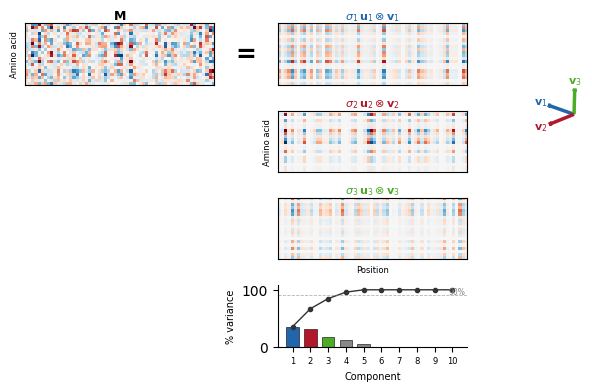

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ── Reproducibility ──
rng = np.random.default_rng(42)

# ── Global style ──
# plt.rcParams.update({
#     'font.family': 'sans-serif',
#     'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
#     'font.size': 7,
#     'axes.labelsize': 7,
#     'axes.titlesize': 8,
#     'xtick.labelsize': 6,
#     'ytick.labelsize': 6,
#     'mathtext.default': 'regular',
# })

# ── Parameters ──
N_POS = 60
N_AA = 20
N_COMPONENTS_TRUE = 5  # rank of the generating matrix

# ── Colours ──
C1 = '#2166ac'  # blue
C2 = '#b2182b'  # red
C3 = '#4dac26'  # green

# ── Generate example matrix (sum of N_COMPONENTS_TRUE rank-1 outer products) ──
M = np.zeros((N_POS, N_AA))
for _ in range(N_COMPONENTS_TRUE):
    M += np.outer(rng.normal(0, 1, N_POS), rng.normal(0, 1, N_AA))
M_centered = M - np.mean(M, axis=1, keepdims=True)

U, S, Vt = np.linalg.svd(M_centered, full_matrices=False)
var_frac = (S ** 2) / np.sum(S ** 2)

# Transposed components: shape (N_AA × N_POS) = (20 × 60), position on x-axis
comp1 = ((U[:, 0:1] * S[0]) @ Vt[0:1, :]).T
comp2 = ((U[:, 1:2] * S[1]) @ Vt[1:2, :]).T
comp3 = ((U[:, 2:3] * S[2]) @ Vt[2:3, :]).T
M_T = M_centered.T

# Shared colour normalisation
vmax = np.max(np.abs(M_T)) * 0.85
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ── Helper ──
def style_matrix_ax(ax):
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)
    ax.set_xticks([])
    ax.set_yticks([])

# ── Figure ──
fig = plt.figure(figsize=(7.2, 4.2))

gs = gridspec.GridSpec(
    7, 4, figure=fig,
    width_ratios=[2.5, 0.2, 2.5, 1.2],
    height_ratios=[1.0, 0.22, 1.0, 0.22, 1.0, 0.22, 1.0],
    wspace=0.2,
    hspace=0.15
)

# ── M matrix (row 0, col 0) ──
ax_M = fig.add_subplot(gs[0, 0])
ax_M.imshow(M_T, aspect='auto', cmap='RdBu_r', norm=norm, interpolation='nearest')
ax_M.set_title('$\\mathbf{M}$', fontsize=9, fontweight='bold', color='black', pad=3)
ax_M.set_ylabel('Amino acid', fontsize=6)
style_matrix_ax(ax_M)

# ── = sign ──
ax_eq = fig.add_subplot(gs[0, 1])
ax_eq.text(0.5, 0.5, '=', fontsize=18, ha='center', va='center', fontweight='bold')
ax_eq.axis('off')

# ── Component 1 (row 0, col 2) ──
ax_c1 = fig.add_subplot(gs[0, 2])
ax_c1.imshow(comp1, aspect='auto', cmap='RdBu_r', norm=norm, interpolation='nearest')
ax_c1.set_title('$\\sigma_1 \\, \\mathbf{u}_1 \\otimes \\mathbf{v}_1$',
                fontsize=8, fontweight='bold', color=C1, pad=3)
style_matrix_ax(ax_c1)

# ── Component 2 (row 2, col 2) ──
ax_c2 = fig.add_subplot(gs[2, 2])
ax_c2.imshow(comp2, aspect='auto', cmap='RdBu_r', norm=norm, interpolation='nearest')
ax_c2.set_title('$\\sigma_2 \\, \\mathbf{u}_2 \\otimes \\mathbf{v}_2$',
                fontsize=8, fontweight='bold', color=C2, pad=3)
ax_c2.set_ylabel('Amino acid', fontsize=6)
style_matrix_ax(ax_c2)

# ── Component 3 (row 4, col 2) ──
ax_c3 = fig.add_subplot(gs[4, 2])
ax_c3.imshow(comp3, aspect='auto', cmap='RdBu_r', norm=norm, interpolation='nearest')
ax_c3.set_title('$\\sigma_3 \\, \\mathbf{u}_3 \\otimes \\mathbf{v}_3$',
                fontsize=8, fontweight='bold', color=C3, pad=3)
ax_c3.set_xlabel('Position', fontsize=6)
style_matrix_ax(ax_c3)

# ── 3D orthogonal axes (rows 0–2, col 3) ──
ax3d = fig.add_subplot(gs[0:3, 3], projection='3d')

arrow_len = 1.0
for d, c, lab in zip(
    [[arrow_len, 0, 0], [0, arrow_len, 0], [0, 0, arrow_len]],
    [C1, C2, C3],
    ['$\\mathbf{v}_1$', '$\\mathbf{v}_2$', '$\\mathbf{v}_3$'],
):
    ax3d.quiver(0, 0, 0, d[0], d[1], d[2],
                arrow_length_ratio=0.12, color=c, linewidth=2.5)
    ax3d.text(d[0] * 1.3, d[1] * 1.3, d[2] * 1.3, lab,
              fontsize=8, color=c, fontweight='bold', ha='center', va='center')

ax3d.set_xlim(-0.1, 1.5)
ax3d.set_ylim(-0.1, 1.5)
ax3d.set_zlim(-0.1, 1.5)
ax3d.set_axis_off()
ax3d.view_init(elev=20, azim=135)

# ── Spectrum (row 6, col 2) ──
ax_sv = fig.add_subplot(gs[6, 2])
n_show = 10
cumvar = np.cumsum(var_frac[:n_show]) * 100
bar_colors = [C1, C2, C3] + ['#888888'] * (n_show - 3)

ax_sv.bar(range(n_show), var_frac[:n_show] * 100, color=bar_colors,
          edgecolor='black', linewidth=0.4, width=0.7)
ax_sv.plot(range(n_show), cumvar, 'o-', color='#333333', markersize=3, linewidth=1)
ax_sv.axhline(90, color='grey', linestyle='--', linewidth=0.6, alpha=0.6)
ax_sv.text(n_show - 0.3, 93, '90%', fontsize=5.5, color='grey', ha='right')
ax_sv.set_xlabel('Component', fontsize=7)
ax_sv.set_ylabel('% variance', fontsize=7)
ax_sv.set_xticks(range(n_show))
ax_sv.set_xticklabels([str(i + 1) for i in range(n_show)], fontsize=6)
ax_sv.set_ylim(0, 108)
ax_sv.spines['top'].set_visible(False)
ax_sv.spines['right'].set_visible(False)

# ── Manually place + signs ──
fig.canvas.draw()
c1_bbox = ax_c1.get_position()
c2_bbox = ax_c2.get_position()
c3_bbox = ax_c3.get_position()

# plus_x = c2_bbox.x0 - 0.015
# fig.text(plus_x, (c1_bbox.y0 + c2_bbox.y1) / 2, '+',
#          fontsize=12, ha='right', va='center', fontweight='bold')
# fig.text(plus_x, (c2_bbox.y0 + c3_bbox.y1) / 2, '+',
#          fontsize=12, ha='right', va='center', fontweight='bold')

plt.savefig('../figures/figure_2/SVD_diagram.pdf')
plt.show()

### Rugged example
PR40A_HUMAN_Tsuboyama_2023_1UZC.csv

In [146]:
df = pd.read_csv('../data_files/megascale_folding/SPA_STAAU_Tsuboyama_2023_1LP1.csv')

sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
fitness = np.array(df['DMS_score'])

# Construct fitness landscape with Hamming graph for DMS data
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)


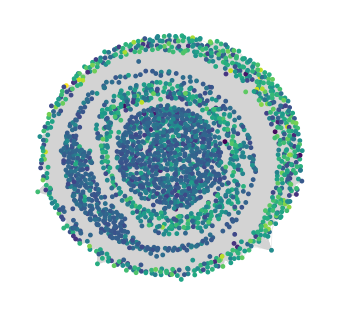

In [147]:
G = landscape.graph

edge_frac = 0.1
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=6,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()

plt.tight_layout()
# plt.savefig('../figures/figure_2/DNJA1_HUMAN_Tsuboyama_2023_2LO1_rugged_example.pdf')
plt.show()

### Smooth example 
MAFG_MOUSE_Tsuboyama_2023_1K1V.csv

In [150]:
df = pd.read_csv('../data_files/megascale_folding/POLG_PESV_Tsuboyama_2023_2MXD.csv')

sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
fitness = np.array(df['DMS_score'])

# Construct fitness landscape with Hamming graph for DMS data
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)

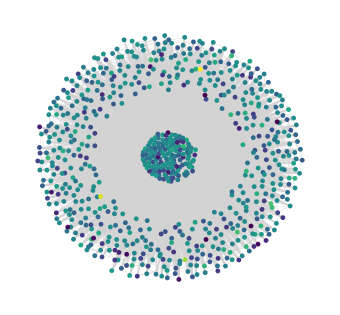

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 0.10
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=6,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

## Sparse datasets

In [22]:
# Prepare file list
file_list = os.listdir('../data_files/sparse_datasets')
file_list = [file for file in file_list if file != '.DS_Store']
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/sparse_datasets/', file))
    df = df.dropna()

    # if len(df) > 4000:
    #     continue

    # Extract sequence objects
    seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

    L = seqs_raw.str.len().max()  # target alignment length
    seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

    sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
    fitness = df["fitness"].to_numpy()

    # Scale K to sqrt of number of sequences
    knn_k = max(int(np.sqrt(len(sequences))), 2)

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences),
        "knn_k": knn_k}

    # Construct fitness landscape
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="knn",
        k=knn_k,
        backend="auto",
        _compute_hamming_edges=False
    )

    
    # Attach fitness values
    layer_name = f"fitness"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Check if there is more than a single connected component and proceed on the largest connected component if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):

        landscape = landscape.get_components()[0]
        continue

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2, prior='uniform')

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

1it [00:02,  2.30s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 39 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
2it [00:03,  1.70s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 1 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
5it [00:08,  1.93s/it]/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 13 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [25]:
out_pkl = Path("../data_files/sparse_datasets/sparse_data_tmap.pkl")
out_json = Path("../data_files/sparse_datasets/sparse_data_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)

In [23]:
results

[{'file': 'LacI_DBD.csv',
  'n_sequences': 1158,
  'knn_k': 34,
  'tmap': {'t_map': 1.5551805709238662,
   't_lower_confidence_interval': 1.1967874253092514,
   't_upper_confidence_interval': 1.8701087143266648,
   't_logposterior_map': -2897.1140623416372,
   'variance_approximate': 0.03026949427538656}},
 {'file': 'PETase.csv',
  'n_sequences': 196,
  'knn_k': 14,
  'tmap': {'t_map': 2.3968880463189777,
   't_lower_confidence_interval': 1.6750227878510051,
   't_upper_confidence_interval': 2.851566263809005,
   't_logposterior_map': -11.625083044899213,
   'variance_approximate': 0.09423353930195028}},
 {'file': 'PPAT.csv',
  'n_sequences': 651,
  'knn_k': 25,
  'tmap': {'t_map': 0.2909353394421664,
   't_lower_confidence_interval': 0.023653217225477967,
   't_upper_confidence_interval': 0.9865832525694116,
   't_logposterior_map': -1474.381878556107,
   'variance_approximate': 0.07118746077115237}},
 {'file': 'cusod.csv',
  'n_sequences': 237,
  'knn_k': 15,
  'tmap': {'t_map': 0.72

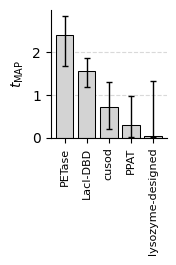

In [29]:
# -----------------------------
# Build dataframe
# -----------------------------
rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": r["tmap"]["t_map"],
        "t_lo": r["tmap"]["t_lower_confidence_interval"],
        "t_hi": r["tmap"]["t_upper_confidence_interval"],
    })

df = pd.DataFrame(rows)

# Coerce numeric + drop non-finite
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["t", "t_lo", "t_hi"]).reset_index(drop=True)

# -----------------------------
# Fix CI ordering (ensure lo <= hi)
# -----------------------------
lo = np.minimum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
hi = np.maximum(df["t_lo"].to_numpy(), df["t_hi"].to_numpy())
df["t_lo"] = lo
df["t_hi"] = hi

# -----------------------------
# Drop poorly fitted datasets (avoid div-by-zero)
# -----------------------------
# eps = 1e-300  # tiny, only to avoid division by zero
# poor_fit = ((df["t_hi"] / np.maximum(df["t_lo"], eps)) >= 10.0) & (df["t_hi"] > 1.0)
# df = df.loc[~poor_fit].reset_index(drop=True)

# -----------------------------
# Ensure t is inside [lo, hi]
# Boundary MAP values (e.g., t=1e-10) can fall just outside profile CI due to
# grid resolution / interpolation artifacts. Keep rows and expand CI to include t.
# -----------------------------
bad_low = df["t"] < df["t_lo"]
bad_high = df["t"] > df["t_hi"]
bad = bad_low | bad_high

df["ci_was_adjusted"] = bad

if bad.any():
    print("Rows where t is outside [t_lo, t_hi] (boundary-adjusting CI to include t):")
    print(df.loc[bad, ["dataset", "t", "t_lo", "t_hi"]])

    # Expand interval only as much as needed to include t.
    df.loc[bad_low, "t_lo"] = df.loc[bad_low, "t"]
    df.loc[bad_high, "t_hi"] = df.loc[bad_high, "t"]

    print(f"Adjusted CI bounds for {int(bad.sum())} datasets; no rows dropped.")

# -----------------------------
# Sort by t descending
# -----------------------------
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# -----------------------------
# Asymmetric error bars (guaranteed non-negative now)
# -----------------------------
t = df["t"].to_numpy()
t_lo = df["t_lo"].to_numpy()
t_hi = df["t_hi"].to_numpy()
yerr = np.vstack([t - t_lo, t_hi - t])

# -----------------------------
# Plot (single bar call; x aligned with errorbar)
# -----------------------------
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(2, 2.75))

ax.bar(
    x,
    t,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=x,
    y=t,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    zorder=3
)

step = 1  # change to 3 if you truly want every 3rd label
ax.set_xticks(x[::step])
ax.set_xticklabels(df["dataset"].iloc[::step], rotation=90, fontsize=8)

ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
# ax.set_yscale("log")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", ls="--", c="0.85", zorder=1)

plt.tight_layout()
plt.savefig("../figures/figure_2/tmap_vs_sparse.pdf")
plt.show()

### Smooth example

In [73]:
df = pd.read_csv('../data_files/sparse_datasets/PETase.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 1 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "


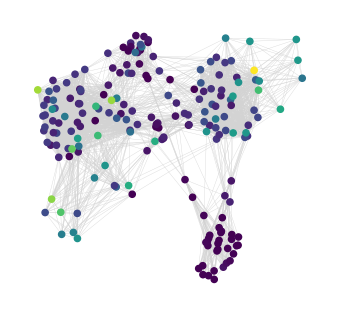

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=20,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

### Rugged example

In [70]:
df = pd.read_csv('../data_files/sparse_datasets/lysozyme_designed.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

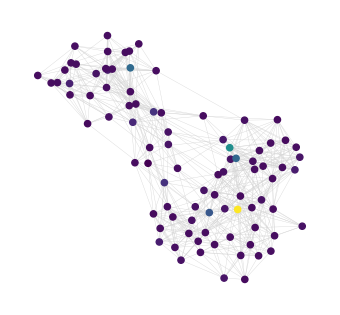

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=20,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()

In [80]:
df = pd.read_csv('../data_files/sparse_datasets/ppat.csv')

df = df.dropna()

# if len(df) > 4000:
#     continue

# Extract sequence objects
seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

L = seqs_raw.str.len().max()  # target alignment length
seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
fitness = df["fitness"].to_numpy()

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="auto",
    _compute_hamming_edges=False
)

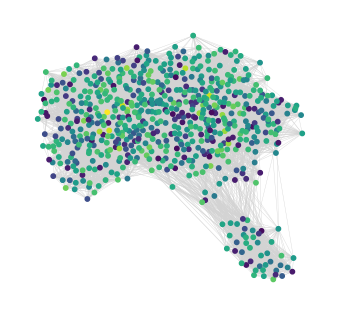

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G = landscape.graph

edge_frac = 1.0
seed = 0  # for reproducibility

rng = np.random.default_rng(seed)
all_edges = list(G.edges())

n_keep = max(1, int(len(all_edges) * edge_frac))
keep_idx = rng.choice(len(all_edges), size=n_keep, replace=False)
edges_sub = [all_edges[i] for i in keep_idx]

# Use a fixed layout so nodes/edges align
# (spring_layout can be slow for large graphs; if G already has positions, use those)
pos = nx.spring_layout(G, seed=seed)

fig, ax = plt.subplots(figsize=(3.5, 3.25))

# Draw only sampled edges
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges_sub,
    edge_color="#d3d3d3",
    width=0.25,
    ax=ax,
)

# Draw all nodes
nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=10,
    node_color=fitness,
    cmap="viridis",
    ax=ax,
)

ax.set_axis_off()
plt.tight_layout()
# plt.savefig(
#     "../figures/figure_2/MAFG_MOUSE_Tsuboyama_2023_1K1V_smooth_example.pdf",
#     bbox_inches="tight"
# )
plt.show()